# CardioSense Phase 1 — X-ray Pipeline (storage-constrained subset)

**Modality:** chest radiograph · **Dataset:** NIH ChestX-ray14 · **Task:** binary
Cardiomegaly · **Views:** PA only · **Model:** DenseNet121, ImageNet-pretrained,
two-stage fine-tuning.

---

## Read this before quoting any number from this notebook

This notebook trains on a **28,384-image subset** of ChestX-ray14, already built and
verified on Drive. It never downloads the dataset and never rebuilds the subset.

### Why a subset exists

ChestX-ray14 is ~45 GB across 112,120 images. Google Drive storage did not allow
keeping it, so the images the cardiomegaly pipeline would actually use were
selected and the rest removed. Of the 72,251 images that had been downloaded,
28,384 were kept: every Cardiomegaly-positive PA view, plus negatives sampled by
patient.

| | |
|---|---|
| Images | 28,384 |
| Positive | 3,138 |
| Negative | 25,246 |
| Negative patients sampled | 11,735 |
| **Subset prevalence** | **3.52%** |
| View | PA |
| Seed | 42 |
| Negative ratio at build time | 8 |

### What this changes, and it matters

The evaluation split is drawn from the subset, so **metrics describe this cohort,
not the full ChestX-ray14 test set**. Two consequences:

1. **PR-AUC is not comparable with published ChestX-ray14 results.** PR-AUC's
   chance level *is* the prevalence. Every PR-AUC below is reported alongside its
   chance level, and the comparison is meaningless without it.
2. **The negative population is narrower.** Sampling 8 negative patients per
   positive covers a smaller slice of "everything that is not cardiomegaly", so the
   model has seen fewer varieties of normal and fewer confounding pathologies.

This is a documented deviation, not a hidden one — see `docs/datasets.md`.

### The second subsampling, and how much it actually matters

The pipeline's config subsamples negatives 8:1 during training. That has already
happened at subset-build time, so Section 4 disables it with
`dataset.negative_ratio = None`.

**Being precise about the size of this problem**, because it is easy to overstate:
your subset was built at ratio 8 (3,138 positives, 25,246 negatives across 11,735
patients ≈ 2.15 images each). Re-applying ratio 8 would target 25,104 negatives and
keep about 11,669 patients — dropping roughly **142 images, 0.6% of the negatives**.
Re-applying the same ratio is close to idempotent.

So the override is correct practice rather than a rescue from disaster. It matters
for three real reasons:

1. It avoids a pointless second random draw that changes the cohort slightly for no
   benefit.
2. It stops `target_report` recording a `negative_subsampling` step that
   misdescribes how the data was actually assembled — the metadata would claim a
   sampling decision this training run did not meaningfully make.
3. **If you ever rebuild the subset at a different ratio, it becomes critical.** A
   subset built at 2:1 and then trained at 8:1 would lose most of its negatives.

Section 6 asserts no second subsampling occurred, so the notebook fails loudly if
the override is ever lost.

### Not a deviation: the ImageNet backbone

`model.pretrained: true` loads torchvision's ImageNet weights and fine-tunes them.
That is standard for medical imaging with limited labelled data, not a shortcut —
112,120 radiographs are far too few to learn general visual features from scratch.
The weights making the clinical decision are trained here; only low-level visual
features are inherited.

## 2. Environment

Mounts Drive, points the library at the existing dataset, installs the repo if
needed. **Downloads nothing.**

In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/artrai73/cardiosense.git"
REPO_DIR = Path("/content/CardioSense")

if REPO_DIR.exists():
    print(f"Repository already exists: {REPO_DIR}")
else:
    print("Cloning CardioSense from GitHub...")
    result = subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("Git clone failed.")

    print("Repository cloned successfully.")

print()
print("Repository:", REPO_DIR)
print("Exists:", REPO_DIR.exists())
print("Source:", REPO_DIR / "src")
print("Notebooks:", REPO_DIR / "notebooks")

Cloning CardioSense from GitHub...
Repository cloned successfully.

Repository: /content/CardioSense
Exists: True
Source: /content/CardioSense/src
Notebooks: /content/CardioSense/notebooks


In [2]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

REPO_DIR = Path("/content/CardioSense")
DRIVE_PROJECT = Path("/content/drive/MyDrive/CardioSense")
DRIVE_DATA = DRIVE_PROJECT / "data"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    if not REPO_DIR.exists():
        raise RuntimeError(
            f"{REPO_DIR} not found. Run notebooks/00_colab_setup.ipynb first — it "
            "clones the repository. This notebook deliberately does not clone, so a "
            "rerun cannot silently replace your working copy."
        )
    os.chdir(REPO_DIR)

    # Point the library at the dataset already on Drive.
    os.environ["CARDIOSENSE_DATA_ROOT"] = str(DRIVE_DATA)

    # Idempotent: pip is a no-op when the package is already installed this way.
    subprocess.run(["pip", "install", "-q", "-r", "requirements-colab.txt"], check=False)
    subprocess.run(["pip", "install", "-q", "-e", "."], check=False)
else:
    here = Path.cwd()
    while not (here / "pyproject.toml").exists() and here != here.parent:
        here = here.parent
    os.chdir(here)
    REPO_DIR = here
    os.environ.setdefault("CARDIOSENSE_DATA_ROOT", str(here / "data"))

src_dir = str(REPO_DIR / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import torch
print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__)
print("CUDA        :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("repository  :", REPO_DIR)
print("data root   :", os.environ["CARDIOSENSE_DATA_ROOT"])

if not torch.cuda.is_available():
    print("\nNo GPU. Runtime -> Change runtime type -> T4 GPU, then rerun this cell.")

Mounted at /content/drive
python      : 3.13.15
torch       : 2.11.0+cu128
CUDA        : True | Tesla T4
repository  : /content/CardioSense
data root   : /content/drive/MyDrive/CardioSense/data


## 3. Imports

Everything comes from `src/cardiosense`. Nothing in this notebook reimplements
logic that already lives in the package.

In [3]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as ShowImage, display

from cardiosense.common.config import load_config
from cardiosense.common.env import get_device, print_environment
from cardiosense.common.io_utils import save_json, save_pickle
from cardiosense.common.paths import PATHS
from cardiosense.common.plots import plot_class_distribution, plot_training_curves
from cardiosense.common.seeding import set_seed
from cardiosense.common.training import count_parameters

from cardiosense.xray.data import (
    build_target, describe_dataset, load_metadata, resolve_nih_root,
    split_by_patient, verify_dataset,
)
from cardiosense.xray.preprocessing import build_transforms, denormalize
from cardiosense.xray.dataset import ChestXrayDataset, build_dataloaders, compute_pos_weight
from cardiosense.xray.baseline import (
    build_feature_matrix, majority_class_baseline, train_pixel_baseline,
)
from cardiosense.xray.models import build_model, model_summary
from cardiosense.xray.trainer import train_model
from cardiosense.xray import evaluate as ev
from cardiosense.xray.explain import run_gradcam_analysis
from cardiosense.xray.predict import XrayPredictor

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
_ = print_environment()

CARDIOSENSE RUNTIME ENVIRONMENT
  Python      : 3.13.15
  Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
  CPU cores   : 2
  Colab       : True
  Git commit  : 10a12af
  GPU         : Tesla T4 (14.56 GB, sm_75)
  CUDA        : 12.8
  Packages    :
      captum         0.9.0
      numpy          2.1.3
      pandas         2.2.3
      scipy          1.16.3
      shap           0.52.0
      sklearn        1.6.1
      torch          2.11.0+cu128
      torchvision    0.26.0+cu128
      wfdb           4.3.1
      xgboost        3.4.1


## 4. Configuration

Loaded from `configs/xray_config.yaml`, then **one in-memory override**:

```python
cfg.dataset["negative_ratio"] = None
```

The YAML file is not touched — the override lives only in this session, so the
repository configuration stays correct for anyone training on the full dataset.

Without it the pipeline draws negatives again. On this subset that costs only about
0.6% of the negatives (see Section 1), but it is a pointless re-sample and it makes
the recorded metadata misdescribe the cohort. On a subset built at a different
ratio it would matter a great deal.

In [4]:
cfg = load_config("xray")

SEED = int(cfg.seed)
set_seed(SEED, strict=bool(cfg.get("strict_determinism", False)))
device = get_device()

# --- the subset override -------------------------------------------------
original_ratio = cfg.dataset.get("negative_ratio")
cfg.dataset["negative_ratio"] = None

RESULTS = PATHS.root / cfg.output.results_dir
MODELS = PATHS.root / cfg.output.models_dir
CHECKPOINTS = MODELS / "checkpoints"
for path in (RESULTS, MODELS, CHECKPOINTS):
    path.mkdir(parents=True, exist_ok=True)

print(f"target          : {cfg.dataset.target_label} (binary)")
print(f"view filter     : {cfg.dataset.filter_view} only")
print(f"negative ratio  : {cfg.dataset.negative_ratio}   "
      f"(YAML says {original_ratio}; disabled in memory for the subset)")
print(f"split strategy  : {cfg.split.strategy}, PATIENT-level")
print(f"image size      : {cfg.preprocessing.image_size}px, ImageNet normalisation")
print(f"model           : DenseNet121 (pretrained={cfg.model.pretrained}), "
      f"freeze {cfg.model.freeze_backbone_epochs} epoch(s), "
      f"unfreeze from {cfg.model.unfreeze_from_block}")
print(f"imbalance       : {cfg.class_imbalance.method}")
print(f"headline metric : {cfg.evaluation.primary_metric}")
print(f"seed            : {SEED}")
print(f"device          : {device}")

assert cfg.dataset.negative_ratio is None, "negative_ratio override failed"
assert str(cfg.dataset.filter_view) == "PA"
assert str(cfg.dataset.target_label) == "Cardiomegaly"
assert bool(cfg.model.pretrained) is True, "ImageNet weights must be enabled"
print("\nconfiguration checks passed")

[seed] seed=42 mode=seeded (cudnn.benchmark on)
[env] device: cuda
[env] gpu   : Tesla T4
[env] memory: 14.56 GB
[env] cuda  : 12.8 | capability sm_75
target          : Cardiomegaly (binary)
view filter     : PA only
negative ratio  : None   (YAML says 8; disabled in memory for the subset)
split strategy  : official, PATIENT-level
image size      : 224px, ImageNet normalisation
model           : DenseNet121 (pretrained=True), freeze 2 epoch(s), unfreeze from denseblock3
imbalance       : pos_weight
headline metric : pr_auc
seed            : 42
device          : cuda

configuration checks passed


## 5. Dataset verification

Runs the library's `verify_dataset`, then adds subset-specific checks it cannot
know about.

The check that matters most: **is the CSV the filtered subset file, or the original
112,120-row one?** The folder contains both `Data_Entry_2017.csv` and
`Data_Entry_2017_v2020.csv`, and the config names the v2020 file first — but if that
file were the unfiltered original, the pipeline would select images that are no
longer on disk and training would fail partway through with `FileNotFoundError`.
Better to catch it here than 40 minutes into a run.

In [5]:
EXPECTED_SUBSET_SIZE = 28_384

root = resolve_nih_root(cfg)
images_dir = root / str(cfg.dataset.images_dir)

library_report = verify_dataset(cfg, root)
print(json.dumps(library_report, indent=2))

checks, failures = [], []

def check(name, passed, detail=""):
    checks.append({"check": name, "status": "PASS" if passed else "FAIL", "detail": detail})
    if not passed:
        failures.append(f"{name}: {detail}")

# --- files present ---
for filename in ("Data_Entry_2017_v2020.csv", "subset_manifest.json"):
    check(f"{filename} present", (root / filename).exists(), str(root / filename))
check("images/ present", images_dir.exists(), str(images_dir))

keep_list_path = root / "subset_keep_list.txt"
check("subset_keep_list.txt present", keep_list_path.exists(),
      "optional; used as a cross-check when available")

# --- the CSV must be the FILTERED one ---
raw_frame = pd.read_csv(root / str(cfg.dataset.metadata_csv))
check("metadata CSV is the FILTERED subset file", len(raw_frame) < 60_000,
      f"{len(raw_frame):,} rows (the unfiltered original has 112,120)")

check(f"CSV row count == {EXPECTED_SUBSET_SIZE:,}", len(raw_frame) == EXPECTED_SUBSET_SIZE,
      f"{len(raw_frame):,} rows")

# --- images on disk ---
on_disk = {p.name for p in images_dir.glob("*.png")}
check(f"image count == {EXPECTED_SUBSET_SIZE:,}", len(on_disk) == EXPECTED_SUBSET_SIZE,
      f"{len(on_disk):,} PNG files")

# --- every CSV image exists ---
csv_names = set(raw_frame[str(cfg.dataset.image_column)].astype(str))
missing = csv_names - on_disk
check("no CSV image missing from disk", not missing,
      f"{len(missing):,} missing" + (f", e.g. {sorted(missing)[:3]}" if missing else ""))

# --- manifest agreement ---
manifest = {}
manifest_path = root / "subset_manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    n_subset = manifest.get("n_subset")
    check("manifest n_subset matches the CSV", n_subset == len(raw_frame),
          f"manifest {n_subset}, CSV {len(raw_frame)}")

if keep_list_path.exists():
    keep_names = {line.strip() for line in keep_list_path.read_text().splitlines()
                  if line.strip()}
    check("keep-list matches the CSV", keep_names == csv_names,
          f"keep-list {len(keep_names):,}, CSV {len(csv_names):,}")

display(pd.DataFrame(checks))

if failures:
    raise RuntimeError(
        "Dataset verification FAILED — training would produce misleading results.\n\n"
        + "\n".join(f"  - {f}" for f in failures)
        + "\n\nFix the dataset before continuing. Do not proceed."
    )
print(f"\nAll checks passed. {len(on_disk):,} images verified at {images_dir}")

2026-09-08 14:32:45 | INFO     | cardiosense.xray.data        | ChestX-ray14 verified at /content/drive/MyDrive/CardioSense/data/xray/nih (28384 images, official lists: False)
2026-09-08 14:32:45 | WARNING  | cardiosense.xray.data        | Official train_val_list.txt / test_list.txt are missing. The pipeline will fall back to a grouped random split by patient, which is still leakage-free but no longer comparable to published splits.
{
  "root": "/content/drive/MyDrive/CardioSense/data/xray/nih",
  "metadata_csv": "/content/drive/MyDrive/CardioSense/data/xray/nih/Data_Entry_2017_v2020.csv",
  "images_dir": "/content/drive/MyDrive/CardioSense/data/xray/nih/images",
  "n_image_files": 28384,
  "has_official_lists": false
}


,check,status,detail
0,Data_Entry_2017_v2020.csv present,PASS,/content/drive/MyDrive/CardioSense/data/xray/n...
1,subset_manifest.json present,PASS,/content/drive/MyDrive/CardioSense/data/xray/n...
2,images/ present,PASS,/content/drive/MyDrive/CardioSense/data/xray/n...
3,subset_keep_list.txt present,PASS,optional; used as a cross-check when available
4,metadata CSV is the FILTERED subset file,PASS,"28,384 rows (the unfiltered original has 112,120)"
5,"CSV row count == 28,384",PASS,"28,384 rows"
6,"image count == 28,384",PASS,"28,384 PNG files"
7,no CSV image missing from disk,PASS,0 missing
8,manifest n_subset matches the CSV,PASS,"manifest 28384, CSV 28384"
9,keep-list matches the CSV,PASS,"keep-list 28,384, CSV 28,384"



All checks passed. 28,384 images verified at /content/drive/MyDrive/CardioSense/data/xray/nih/images


## 6. Subset metadata

The filtered CSV is used exactly as it is. `build_target` applies the view filter
and the label rule; with `negative_ratio = None` it performs **no** further
subsampling.

In [6]:
frame = load_metadata(cfg, root)
print(f"rows loaded: {len(frame):,}")

frame, target_report = build_target(frame, cfg)
print(json.dumps(target_report, indent=2))

n_pos = int(frame.target.sum())
n_neg = int(len(frame) - n_pos)
pos_patients = frame.loc[frame.target == 1, str(cfg.dataset.patient_column)].nunique()

print()
print(f"images after view filter : {len(frame):,}")
print(f"unique patients          : {frame[str(cfg.dataset.patient_column)].nunique():,}")
print(f"positive                 : {n_pos:,}")
print(f"negative                 : {n_neg:,}")
print(f"prevalence               : {frame.target.mean():.4f}")
print(f"unique positive patients : {pos_patients:,}")
print(f"\nview distribution:\n{frame['View Position'].value_counts().to_string()}")

# build_target must NOT have subsampled again — that already happened when the
# subset was created. If it had, `negative_subsampling` would appear in the report
# and rows_out would be a fraction of what went in.
assert "negative_subsampling" not in target_report, (
    "build_target subsampled negatives a SECOND time. cfg.dataset.negative_ratio "
    f"is {cfg.dataset.negative_ratio!r} — it must be None for this subset.\n"
    f"Report: {target_report.get('negative_subsampling')}"
)
print(f"\nno second subsampling: rows_out {target_report['rows_out']:,}, "
      f"final prevalence {target_report['final_prevalence']:.4f}")

2026-09-08 14:33:06 | INFO     | cardiosense.xray.data        | Loaded 28384 rows from Data_Entry_2017_v2020.csv (12478 patients)
rows loaded: 28,384
2026-09-08 14:33:06 | INFO     | cardiosense.xray.data        | View filter PA: 28384 -> 28384 images
2026-09-08 14:33:06 | INFO     | cardiosense.xray.data        | Target 'Cardiomegaly': 1000 positives of 28384 images (3.52%) across 12478 patients
2026-09-08 14:33:06 | WARNING  | cardiosense.xray.data        | Prevalence is 3.52%. A model predicting 'negative' for everything scores 96.5% accuracy and is clinically worthless — PR-AUC is the headline metric, not accuracy.
{
  "rows_in": 28384,
  "target_label": "Cardiomegaly",
  "prevalence_all_views": 0.03523,
  "positives_all_views": 1000,
  "view_filter": "PA",
  "rows_after_view_filter": 28384,
  "prevalence_after_view_filter": 0.03523,
  "rows_out": 28384,
  "n_patients": 12478,
  "positives": 1000,
  "negatives": 27384,
  "final_prevalence": 0.03523,
  "images_per_patient": 2.275
}


## 7. EDA

Lightweight by design: class balance, patient-level structure, and a look at real
images. Nothing that touches all 28,384 files.

images per patient: mean 2.27, max 100


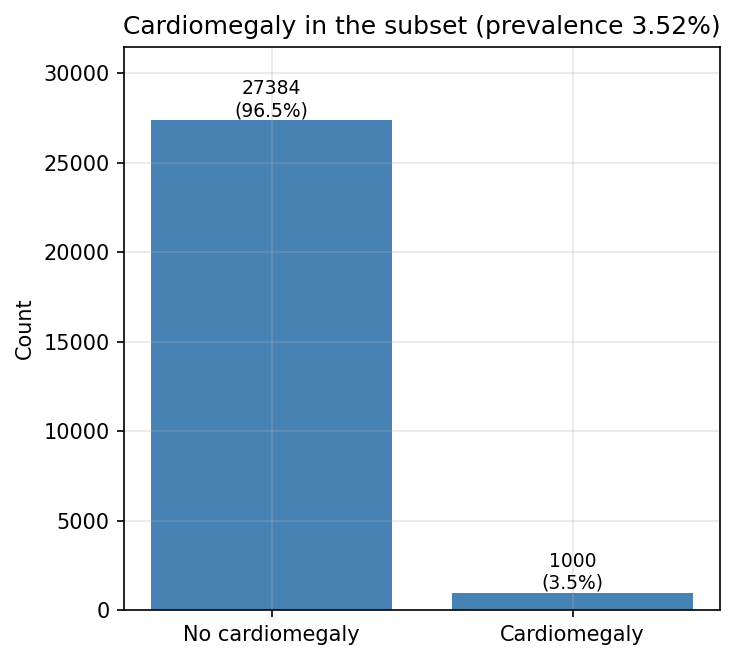


patients                 : 12,478
  with a positive film   : 743
  images per patient     : mean 2.27, max 100

A patient contributing several films is why the split below must be by patient:
image-level splitting would put the same person on both sides.


In [7]:
description = describe_dataset(frame, cfg)
save_json(description, RESULTS / "dataset_description.json")
print(f"images per patient: mean {description['images_per_patient']['mean']}, "
      f"max {description['images_per_patient']['max']}")

plot_class_distribution(
    {"No cardiomegaly": int((frame.target == 0).sum()),
     "Cardiomegaly": int((frame.target == 1).sum())},
    RESULTS / "class_distribution.png",
    title=f"Cardiomegaly in the subset (prevalence {frame.target.mean():.2%})",
)
display(ShowImage(filename=str(RESULTS / "class_distribution.png")))

patient_col = str(cfg.dataset.patient_column)
per_patient = frame.groupby(patient_col).agg(
    images=("target", "size"), any_positive=("target", "max"))

print(f"\npatients                 : {len(per_patient):,}")
print(f"  with a positive film   : {int(per_patient.any_positive.sum()):,}")
print(f"  images per patient     : mean {per_patient.images.mean():.2f}, "
      f"max {per_patient.images.max()}")
print("\nA patient contributing several films is why the split below must be by "
      "patient:\nimage-level splitting would put the same person on both sides.")

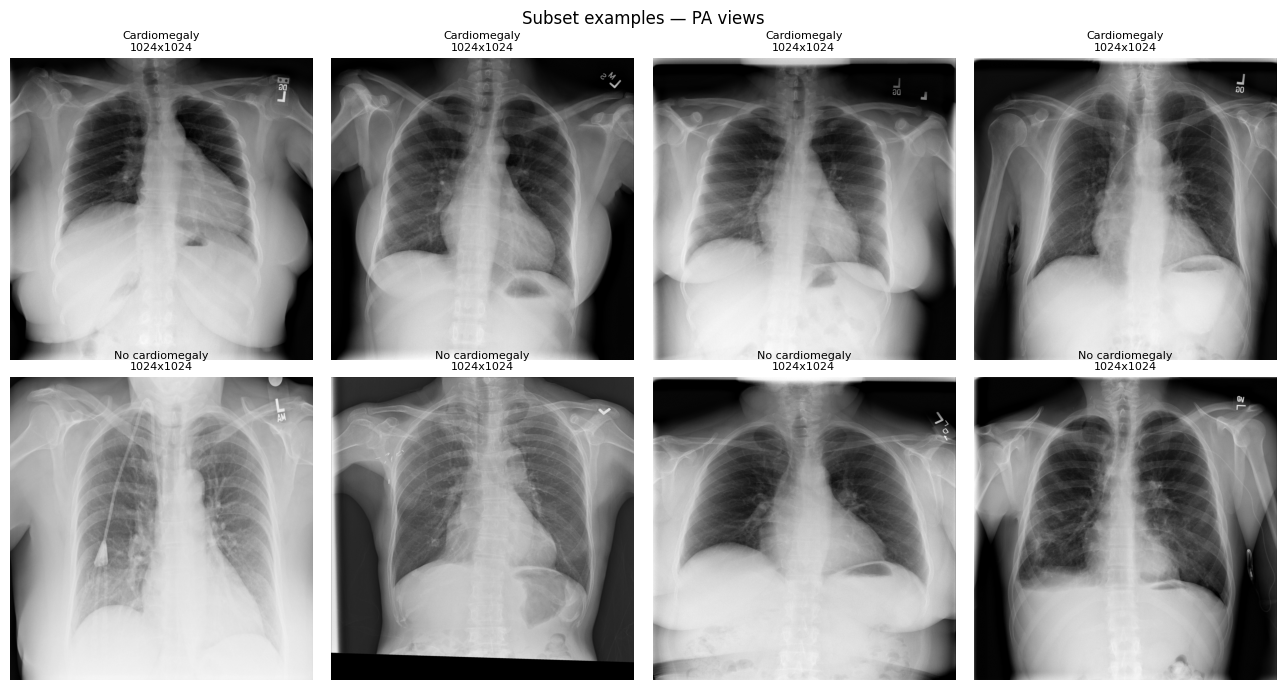

Cardiomegaly is a cardiothoracic-ratio judgement. It is not obvious by eye at this size,
which is worth remembering when reading the Grad-CAM maps later.


In [8]:
# What the model actually sees. Positives on top, negatives below.
from PIL import Image

rng = np.random.default_rng(SEED)
pos = frame[frame.target == 1].sample(4, random_state=SEED)
neg = frame[frame.target == 0].sample(4, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for row, (subset_frame, label) in enumerate([(pos, "Cardiomegaly"), (neg, "No cardiomegaly")]):
    for col, (_, record) in enumerate(subset_frame.iterrows()):
        image = Image.open(images_dir / record[str(cfg.dataset.image_column)])
        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(f"{label}\n{image.size[0]}x{image.size[1]}", fontsize=8)
        axes[row, col].axis("off")
fig.suptitle("Subset examples — PA views", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS / "sample_images.png", dpi=110, bbox_inches="tight")
plt.show()

print("Cardiomegaly is a cardiothoracic-ratio judgement. It is not obvious by eye at "
      "this size,\nwhich is worth remembering when reading the Grad-CAM maps later.")

## 8. Preprocessing and augmentation

From `cardiosense.xray.preprocessing`. Train gets random augmentation; validation
and test are **deterministic** — a random transform at evaluation would make the
metric depend on the random seed rather than on the model.

Note the augmentation config refuses horizontal flips. A mirrored chest radiograph
depicts dextrocardia, a real and different condition, so flipping would teach the
model that a right-sided heart is normal.

In [9]:
transforms = build_transforms(cfg)
for name, transform in transforms.items():
    print(f"{name:6} : {transform}")

print("\naugmentation config:")
print(json.dumps(cfg.augmentation.to_dict(), indent=2))

2026-09-08 14:33:23 | INFO     | cardiosense.xray.preprocessing | Train augmentation: crop scale (0.9, 1.0), rotation +/-7 deg, translate (0.05, 0.05), brightness/contrast +/-0.10/0.10, NO horizontal flip
train  : Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0), ratio=(0.95, 1.05), interpolation=bilinear, antialias=True)
    RandomAffine(degrees=[-7.0, 7.0], translate=(0.05, 0.05))
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
val    : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
test   : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normali

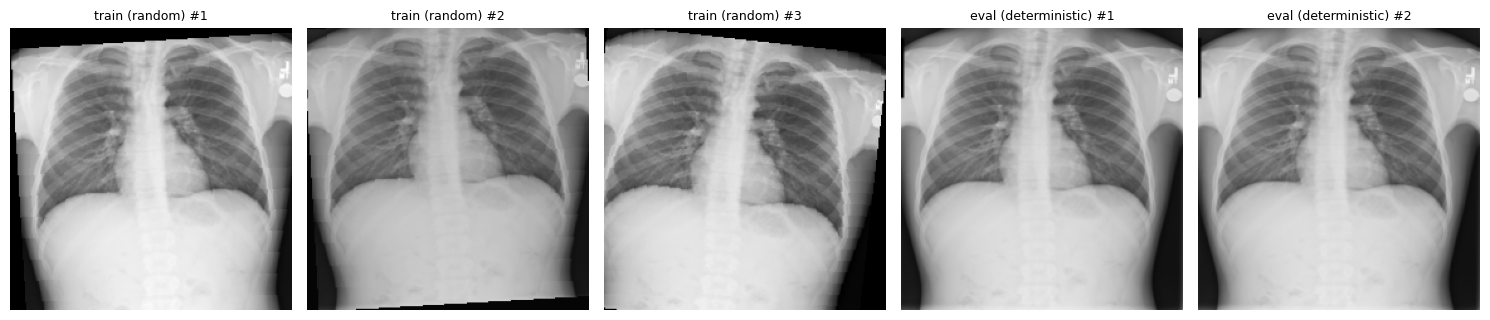

The two eval panels are identical. That is the point.


In [10]:
# The same image through the train transform three times, then through eval twice.
sample_path = images_dir / frame.iloc[0][str(cfg.dataset.image_column)]
original = Image.open(sample_path).convert("L")

fig, axes = plt.subplots(1, 5, figsize=(15, 3.4))
for i in range(3):
    tensor = transforms["train"](original.copy())
    axes[i].imshow(denormalize(tensor, cfg).permute(1, 2, 0).numpy())
    axes[i].set_title(f"train (random) #{i+1}", fontsize=9)
for i in range(2):
    tensor = transforms["test"](original.copy())
    axes[3 + i].imshow(denormalize(tensor, cfg).permute(1, 2, 0).numpy())
    axes[3 + i].set_title(f"eval (deterministic) #{i+1}", fontsize=9)
for ax in axes:
    ax.axis("off")
fig.tight_layout()
fig.savefig(RESULTS / "augmentation_examples.png", dpi=110, bbox_inches="tight")
plt.show()

print("The two eval panels are identical. That is the point.")

## 9. Patient-level split

`split_by_patient` asserts zero patient overlap and records the check in its
summary, so it is visible rather than merely believed.

The subset folder has no `train_val_list.txt` / `test_list.txt`, so the library
falls back to **`grouped_random`** — a patient-level random split. Still
leakage-free, but no longer comparable to published ChestX-ray14 splits. That is
recorded in the summary and repeated in the limitations.

The cell also asserts the splits retained essentially the whole subset, which
catches a lost override or an unexpected filtering step.

In [11]:
splits = split_by_patient(frame, cfg, root)
save_json(splits["summary"], RESULTS / "split_summary.json")

print("patient overlap (must be all zero):", splits["summary"]["patient_overlap"])
display(pd.DataFrame(splits["summary"]["splits"]).T)

y_train = splits["train"].target.to_numpy()
y_val = splits["val"].target.to_numpy()
y_test = splits["test"].target.to_numpy()

total = len(splits["train"]) + len(splits["val"]) + len(splits["test"])
print(f"\ntotal across splits: {total:,}  (subset holds {len(frame):,})")

for pair, overlap in splits["summary"]["patient_overlap"].items():
    assert overlap == 0, f"PATIENT LEAKAGE between {pair}: {overlap} shared patients"

assert total > 0.9 * len(frame), (
    f"Only {total:,} of {len(frame):,} images reached the splits. Negatives were "
    "probably subsampled a second time — check cfg.dataset.negative_ratio is None."
)
print("no patient leakage; the whole subset reached the splits")

for name, y in (("train", y_train), ("val", y_val), ("test", y_test)):
    print(f"  {name:5} {len(y):>6,} images, prevalence {y.mean():.4f}, "
          f"{int(y.sum()):>4} positive")

2026-09-08 14:33:25 | WARNING  | cardiosense.xray.data        | Official lists unavailable; falling back to grouped_random.
2026-09-08 14:33:25 | INFO     | cardiosense.xray.data        | train  20251 images |  9016 patients |  694 positive (3.43%)
2026-09-08 14:33:25 | INFO     | cardiosense.xray.data        | val     3722 images |  1591 patients |  162 positive (4.35%)
2026-09-08 14:33:25 | INFO     | cardiosense.xray.data        | test    4411 images |  1871 patients |  144 positive (3.26%)
2026-09-08 14:33:25 | INFO     | cardiosense.xray.data        | Patient overlap between splits: {'train_val': 0, 'train_test': 0, 'val_test': 0} (all zero = leakage-free)
patient overlap (must be all zero): {'train_val': 0, 'train_test': 0, 'val_test': 0}


,n_images,n_patients,n_positive,prevalence,images_per_patient
train,20251.0,9016.0,694.0,0.03427,2.25
val,3722.0,1591.0,162.0,0.04352,2.34
test,4411.0,1871.0,144.0,0.03265,2.36



total across splits: 28,384  (subset holds 28,384)
no patient leakage; the whole subset reached the splits
  train 20,251 images, prevalence 0.0343,  694 positive
  val    3,722 images, prevalence 0.0435,  162 positive
  test   4,411 images, prevalence 0.0326,  144 positive


## 10. Baselines — Experiment X-A

Two, and the first exists to make a point.

**Majority class** predicts "no cardiomegaly" for everything. At 3.5% prevalence it
scores about 96.5% accuracy and finds zero cases. That single row is why accuracy is
not the headline metric here.

**Pixel logistic regression** on 32x32 thumbnails plus intensity histograms: a
genuine floor for how much of the task is solvable from crude image statistics
alone. DenseNet121 has to beat it to have earned its complexity.

In [ ]:
experiments = {}

majority = majority_class_baseline(y_train, y_test)
experiments["majority_class"] = {
    "metrics": {"at_tuned_threshold": majority["metrics"]},
    "parameters": 1, "train_seconds": 0.0,
}

print(f"accuracy : {majority['metrics']['accuracy']:.4f}   <- looks excellent")
print(f"recall   : {majority['metrics']['recall']:.4f}   <- finds nothing")
print(f"TP       : {int(majority['metrics']['tp'])} of {int(y_test.sum())} positives")
print("\nA model can be 96% accurate here and clinically worthless.")

2026-08-30 13:38:47 | INFO     | cardiosense.xray.baseline    | Majority-class baseline: accuracy 0.9674, recall 0.0000, PR-AUC 0.0326. It identifies 0 of 144 positive cases — which is why accuracy is not the headline metric.
accuracy : 0.9674   <- looks excellent
recall   : 0.0000   <- finds nothing
TP       : 0 of 144 positives

A model can be 96% accurate here and clinically worthless.


In [ ]:
# Feature extraction reads every image once at 32x32. A few minutes on Colab.
RUN_PIXEL_BASELINE = True

if RUN_PIXEL_BASELINE:
    start = time.time()
    X_train = build_feature_matrix(splits["train"], images_dir, cfg)
    X_val = build_feature_matrix(splits["val"], images_dir, cfg)
    X_test = build_feature_matrix(splits["test"], images_dir, cfg)

    pixel = train_pixel_baseline(X_train, y_train, X_val, cfg, X_test=X_test)
    threshold_pixel, _ = ev.tune_threshold(y_val, pixel["val_prob"], cfg)
    metrics_pixel = ev.evaluate_binary(y_test, pixel["test_prob"], threshold_pixel, cfg,
                                       split_name="test/pixel_baseline")

    experiments["logreg_pixel_features"] = {
        "metrics": metrics_pixel,
        "parameters": pixel["parameters"],
        "train_seconds": round(time.time() - start, 2),
    }
    save_pickle(pixel["model"], MODELS / "xray_baseline.pkl")

    print(f"\npixel baseline PR-AUC {metrics_pixel['at_tuned_threshold']['pr_auc']:.4f} "
          f"(chance = prevalence {metrics_pixel['prevalence']:.4f})")
    print(f"                ROC-AUC {metrics_pixel['at_tuned_threshold']['roc_auc']:.4f}")
else:
    print("Pixel baseline skipped. The comparison table will show two rows, not three.")

extracting image features:   0%|          | 0/20251 [00:00<?, ?it/s]

2026-08-30 14:16:09 | INFO     | cardiosense.xray.baseline    | Feature matrix: (20251, 1056) (1024 downsampled pixels + 32 histogram bins)


extracting image features:   0%|          | 0/3722 [00:00<?, ?it/s]

2026-08-30 14:18:01 | INFO     | cardiosense.xray.baseline    | Feature matrix: (3722, 1056) (1024 downsampled pixels + 32 histogram bins)


extracting image features:   0%|          | 0/4411 [00:00<?, ?it/s]

2026-08-30 14:20:15 | INFO     | cardiosense.xray.baseline    | Feature matrix: (4411, 1056) (1024 downsampled pixels + 32 histogram bins)
2026-08-30 14:20:15 | INFO     | cardiosense.xray.baseline    | Fitting pixel-feature baseline: 1056 features, 20251 images
2026-08-30 14:20:43 | INFO     | cardiosense.xray.baseline    | Pixel baseline fitted in 28.2s


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2026-08-30 14:20:44 | INFO     | cardiosense.xray.evaluate    | Threshold tuned on validation (max_f1): 0.552 (f1 = 0.1784)
2026-08-30 14:20:47 | INFO     | cardiosense.xray.evaluate    | [test/pixel_baseline] PR-AUC 0.0817 (chance 0.0326, lift 2.5x) | ROC-AUC 0.7417 | recall 0.444 | precision 0.077 | accuracy 0.8078
2026-08-30 14:20:47 | INFO     | cardiosense.xray.evaluate    |     For scale: predicting 'no cardiomegaly' for every image would score 0.9674 accuracy and find 0 of 144 cases.

pixel baseline PR-AUC 0.0817 (chance = prevalence 0.0326)
                ROC-AUC 0.7417


## 11. DenseNet121 — Experiment X-B

ImageNet-pretrained, from `cardiosense.xray.models`. The classifier head is
replaced with dropout plus a single linear layer to one logit.

`pos_weight` is the **only** imbalance correction applied. A weighted sampler as
well would apply the correction twice and produce wildly over-confident
probabilities — which would then poison the confidence-aware fusion in Phase 2.

In [ ]:
loaders = build_dataloaders(splits, images_dir, transforms, cfg)
print({name: len(loader.dataset) for name, loader in loaders.items()})

pos_weight = None
if str(cfg.class_imbalance.method) == "pos_weight":
    pos_weight = compute_pos_weight(y_train)
    print(f"\npos_weight = {float(pos_weight):.2f}")
    print("Each positive image contributes as much to the loss as that many negatives.")

model = build_model(cfg).to(device)
architecture = model_summary(
    model, input_shape=(2, 3, int(cfg.preprocessing.image_size),
                        int(cfg.preprocessing.image_size)))
print("\n" + json.dumps(architecture, indent=2))

trainable = count_parameters(model, trainable_only=True)
total_params = count_parameters(model, trainable_only=False)
print(f"\ntrainable now : {trainable:,} of {total_params:,} "
      f"({trainable / total_params:.1%})")
print(f"frozen        : {total_params - trainable:,}")
print(f"\nStage 1 trains the head only for {cfg.model.freeze_backbone_epochs} epoch(s),")
print(f"then unfreezes from {cfg.model.unfreeze_from_block} at a lower learning rate.")

2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | train loader: 20251 images, 633 batches, prevalence 0.0343
2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | val   loader: 3722 images, 117 batches, prevalence 0.0435
2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | test  loader: 4411 images, 138 batches, prevalence 0.0326
{'train': 20251, 'val': 3722, 'test': 4411}
2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | pos_weight = 28.18 (19557 negative / 694 positive)

pos_weight = 28.18
Each positive image contributes as much to the loss as that many negatives.
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 111MB/s] 


2026-08-30 14:20:48 | INFO     | cardiosense.xray.models      | Loaded ImageNet pretrained DenseNet121 weights.
2026-08-30 14:20:48 | INFO     | cardiosense.xray.models      | Backbone frozen: 1025 of 6954881 parameters trainable (0.0%)

{
  "class": "XrayDenseNet121",
  "total": 6954881,
  "trainable": 1025,
  "size_mb": 26.53,
  "pretrained": true,
  "output_shape": [
    2,
    1
  ],
  "feature_map_shape": [
    2,
    1024,
    7,
    7
  ]
}

trainable now : 1,025 of 6,954,881 (0.0%)
frozen        : 6,953,856

Stage 1 trains the head only for 2 epoch(s),
then unfreezes from denseblock3 at a lower learning rate.


## 12. Training

`train_model` handles both stages, AMP, checkpointing and early stopping. It
monitors **validation PR-AUC**, not accuracy — at 3.5% prevalence accuracy would
select a model that predicts "negative" for everything.

Checkpoints go to Drive, so a dropped Colab runtime resumes rather than restarts.

In [12]:
loaders = build_dataloaders(splits, images_dir, transforms, cfg)
print({name: len(loader.dataset) for name, loader in loaders.items()})

pos_weight = None
if str(cfg.class_imbalance.method) == "pos_weight":
    pos_weight = compute_pos_weight(y_train)
    print(f"\npos_weight = {float(pos_weight):.2f}")
    print("Each positive image contributes as much to the loss as that many negatives.")
model = build_model(cfg).to(device)


2026-09-08 14:33:25 | INFO     | cardiosense.xray.dataset     | train loader: 20251 images, 633 batches, prevalence 0.0343
2026-09-08 14:33:25 | INFO     | cardiosense.xray.dataset     | val   loader: 3722 images, 117 batches, prevalence 0.0435
2026-09-08 14:33:25 | INFO     | cardiosense.xray.dataset     | test  loader: 4411 images, 138 batches, prevalence 0.0326
{'train': 20251, 'val': 3722, 'test': 4411}
2026-09-08 14:33:25 | INFO     | cardiosense.xray.dataset     | pos_weight = 28.18 (19557 negative / 694 positive)

pos_weight = 28.18
Each positive image contributes as much to the loss as that many negatives.
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 97.0MB/s]


2026-09-08 14:33:26 | INFO     | cardiosense.xray.models      | Loaded ImageNet pretrained DenseNet121 weights.
2026-09-08 14:33:26 | INFO     | cardiosense.xray.models      | Backbone frozen: 1025 of 6954881 parameters trainable (0.0%)


2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | train loader: 20251 images, 633 batches, prevalence 0.0343
2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | val   loader: 3722 images, 117 batches, prevalence 0.0435
2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | test  loader: 4411 images, 138 batches, prevalence 0.0326
{'train': 20251, 'val': 3722, 'test': 4411}
2026-08-30 14:20:47 | INFO     | cardiosense.xray.dataset     | pos_weight = 28.18 (19557 negative / 694 positive)

pos_weight = 28.18
Each positive image contributes as much to the loss as that many negatives.
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 111MB/s] 


2026-08-30 14:20:48 | INFO     | cardiosense.xray.models      | Loaded ImageNet pretrained DenseNet121 weights.
2026-08-30 14:20:48 | INFO     | cardiosense.xray.models      | Backbone frozen: 1025 of 6954881 parameters trainable (0.0%)

{
  "class": "XrayDenseNet121",
  "total": 6954881,
  "trainable": 1025,
  "size_mb": 26.53,
  "pretrained": true,
  "output_shape": [
    2,
    1
  ],
  "feature_map_shape": [
    2,
    1024,
    7,
    7
  ]
}

trainable now : 1,025 of 6,954,881 (0.0%)
frozen        : 6,953,856

Stage 1 trains the head only for 2 epoch(s),
then unfreezes from denseblock3 at a lower learning rate.


In [ ]:
training_result = train_model(model, loaders, cfg, device, CHECKPOINTS,
                              pos_weight=pos_weight)

print(f"\nbest {training_result['monitor']} = {training_result['best_value']:.4f} "
      f"at epoch {training_result['best_epoch']}")
print(f"epochs run : {training_result['epochs_run']} "
      f"(resumed from epoch {training_result['resumed_from']})")
print(f"time       : {training_result['total_seconds']:.0f}s "
      f"({training_result['seconds_per_epoch']:.1f}s/epoch)")
if training_result.get("unfreeze"):
    print(f"unfrozen   : {training_result['unfreeze']['trainable_blocks']} "
          f"({training_result['unfreeze']['trainable_fraction']:.1%} of parameters)")

display(pd.DataFrame(training_result["history"]).round(4))

2026-09-07 17:12:59 | INFO     | cardiosense.xray.trainer     | Optimizer adamw: head lr 3.00e-04, backbone lr 5.00e-05
2026-09-07 17:12:59 | INFO     | cardiosense.xray.trainer     | Cosine schedule over 15 epochs with 1 warmup epoch(s).
2026-09-07 17:12:59 | INFO     | cardiosense.xray.trainer     | Training DenseNet121: epochs 1-15, device=cuda, AMP=True, monitor=val_pr_auc


epoch 1/15 [train]:   0%|          | 0/633 [00:00<?, ?it/s]

2026-09-07 18:39:02 | INFO     | cardiosense.common.training  | New best val_pr_auc = 0.05678 at epoch 0 -> best.pt
2026-09-07 18:39:02 | INFO     | cardiosense.xray.trainer     | epoch  1/15 [head-only] | train loss 1.5607 | val loss 2.0064 | PR-AUC 0.0568 | ROC-AUC 0.5893 | recall 0.049 | lr 3.00e-04  <- best


epoch 2/15 [train]:   0%|          | 0/633 [00:00<?, ?it/s]

2026-09-07 18:46:27 | INFO     | cardiosense.common.training  | New best val_pr_auc = 0.06742 at epoch 1 -> best.pt
2026-09-07 18:46:27 | INFO     | cardiosense.xray.trainer     | epoch  2/15 [head-only] | train loss 1.4256 | val loss 1.5444 | PR-AUC 0.0674 | ROC-AUC 0.6341 | recall 0.389 | lr 3.00e-04  <- best
2026-09-07 18:46:27 | INFO     | cardiosense.xray.trainer     | Stage 2: unfreezing the backbone from denseblock3 at lr 4.94e-05
2026-09-07 18:46:27 | INFO     | cardiosense.xray.models      | Backbone unfrozen from denseblock3: 5525249 of 6954881 parameters trainable (79.4%)


...

epoch 10/15 [train]:   0%|          | 0/633 [00:00<?, ?it/s]

2026-09-07 19:48:50 | INFO     | cardiosense.xray.trainer     | epoch 10/15 [fine-tune] | train loss 0.4445 | val loss 3.9073 | PR-AUC 0.3394 | ROC-AUC 0.8636 | recall 0.414 | lr 1.17e-04


epoch 11/15 [train]:   0%|          | 0/633 [00:00<?, ?it/s]

2026-09-07 19:56:36 | INFO     | cardiosense.common.training  | Early stopping: no improvement in 4 epochs (best=0.40396 at epoch 7)
2026-09-07 19:56:37 | INFO     | cardiosense.xray.trainer     | epoch 11/15 [fine-tune] | train loss 0.3600 | val loss 4.9803 | PR-AUC 0.3394 | ROC-AUC 0.8319 | recall 0.296 | lr 8.49e-05
2026-09-07 19:56:37 | INFO     | cardiosense.xray.trainer     | Early stopping at epoch 11 (best val_pr_auc = 0.4040 at epoch 7).
2026-09-07 19:56:37 | INFO     | cardiosense.common.training  | Loaded weights from best.pt (epoch 6)
2026-09-07 19:56:37 | INFO     | cardiosense.xray.trainer     | Training complete in 9817.9s. Best val_pr_auc = 0.4040 at epoch 7.

best val_pr_auc = 0.4040 at epoch 7
epochs run : 11 (resumed from epoch 0)
time       : 9818s (892.5s/epoch)
unfrozen   : ['denseblock3', 'transition3', 'denseblock4', 'norm5'] (79.4% of parameters)


,train_loss,val_loss,val_roc_auc,val_pr_auc,val_f1,val_recall,learning_rate
0,1.5607,2.0064,0.5893,0.0568,0.0544,0.0494,0.0003
1,1.4256,1.5444,0.6341,0.0674,0.1214,0.3889,0.0003
2,1.5192,1.6920,0.8894,0.3180,0.3833,0.4259,0.0003
3,1.1082,1.4939,0.8929,0.3726,0.3766,0.5556,0.0003
4,1.0189,1.5421,0.9126,0.3803,0.4213,0.5370,0.0003
5,0.8795,1.7678,0.9083,0.3788,0.4410,0.5309,0.0002
6,0.7522,1.6476,0.9035,0.4040,0.4165,0.6852,0.0002
7,0.6327,2.8812,0.8857,0.3765,0.4100,0.4568,0.0002
8,0.5492,3.4987,0.8631,0.3573,0.4142,0.3951,0.0001
9,0.4445,3.9073,0.8636,0.3394,0.4201,0.4136,0.0001


load best weights

In [13]:
from pathlib import Path
import torch

WEIGHTS = Path(
    "/content/drive/MyDrive/CardioSense/models/xray/"
    "xray_densenet121_best_epoch7_pr_auc_0.4040.pt"
)

print("Weights:", WEIGHTS)
print("Exists:", WEIGHTS.exists())

if not WEIGHTS.exists():
    raise FileNotFoundError(f"Could not find: {WEIGHTS}")

# This checkpoint was created by our own training run, so it is trusted.
checkpoint = torch.load(
    WEIGHTS,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded.")
print("Type:", type(checkpoint))

if isinstance(checkpoint, dict) and "model_state" in checkpoint:
    state_dict = checkpoint["model_state"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)

# Remaining work can run on CPU
device = torch.device("cpu")
model = model.to(device)
model.eval()

use_amp = False

print("\nBEST X-RAY WEIGHTS LOADED SUCCESSFULLY")
print("Device:", device)

Weights: /content/drive/MyDrive/CardioSense/models/xray/xray_densenet121_best_epoch7_pr_auc_0.4040.pt
Exists: True
Checkpoint loaded.
Type: <class 'dict'>

BEST X-RAY WEIGHTS LOADED SUCCESSFULLY
Device: cpu


## 13. Training curves

In [ ]:
plot_training_curves(
    training_result["history"], RESULTS / "training_curve.png",
    loss_keys=("train_loss", "val_loss"),
    metric_keys=("val_pr_auc", "val_roc_auc", "val_recall"),
    best_epoch=training_result["best_epoch"],
    title="DenseNet121 (subset) — training history",
)
display(ShowImage(filename=str(RESULTS / "training_curve.png")))

print(f"Best epoch {training_result['best_epoch']} by {training_result['monitor']}.")
print("A validation PR-AUC that plateaus while training loss keeps falling is the "
      "point\nwhere the model starts memorising rather than generalising.")

NameError: name 'training_result' is not defined

## 14. Operating threshold — validation only

Tuned on validation and then frozen. The test split is not consulted; tuning on it
would report the best threshold *for the test set*, which is not a number that
generalises.

0.5 is almost always wrong after `pos_weight` training: the loss weighting shifts
the logit scale deliberately, so the operating point moves with it.

In [16]:
# Recreate validation DataLoader without multiprocessing workers
val_loader = torch.utils.data.DataLoader(
    loaders["val"].dataset,
    batch_size=loaders["val"].batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Validation loader recreated")
print("Samples:", len(val_loader.dataset))
print("Batch size:", val_loader.batch_size)
print("Workers:", val_loader.num_workers)

Validation loader recreated
Samples: 3722
Batch size: 32
Workers: 0


In [20]:
# Move model back to the GPU
device = torch.device("cuda")

model = model.to(device)
model.eval()

use_amp = True

print("device =", device)
print("model device =", next(model.parameters()).device)
print("GPU =", torch.cuda.get_device_name(0))
print("AMP =", use_amp)

device = cuda
model device = cuda:0
GPU = Tesla T4
AMP = True


In [21]:
val_loader = torch.utils.data.DataLoader(
    loaders["val"].dataset,
    batch_size=loaders["val"].batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Validation loader ready")
print("Samples:", len(val_loader.dataset))
print("Workers:", val_loader.num_workers)

Validation loader ready
Samples: 3722
Workers: 0


In [24]:
import time
import numpy as np
import torch

model.eval()

val_prob_list = []
val_true_list = []
val_idx_list = []

t0 = time.time()

with torch.no_grad():
    for batch in val_loader:
        x = batch[0].to(device, non_blocking=True)
        y = batch[1]

        with torch.amp.autocast("cuda", enabled=True):
            logits = model(x)

        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()

        val_prob_list.append(probs)
        val_true_list.append(y.cpu().numpy())

elapsed = time.time() - t0

val_prob = np.concatenate(val_prob_list)
val_true = np.concatenate(val_true_list)

print(f"Validation inference complete in {elapsed:.1f} seconds")
print("Samples:", len(val_prob))
print("Positive:", int(val_true.sum()))
print("Negative:", int(len(val_true) - val_true.sum()))

Validation inference complete in 108.2 seconds
Samples: 3722
Positive: 162
Negative: 3560


In [26]:
#del
threshold, threshold_info = ev.tune_threshold(
    val_true,
    val_prob,
    cfg
)

save_json(
    threshold_info,
    RESULTS / "threshold.json"
)

print(json.dumps(threshold_info, indent=2))

val_metrics = ev.evaluate_binary(
    val_true,
    val_prob,
    threshold,
    cfg,
    split_name="validation",
    with_ci=False
)

tuned_val = val_metrics["at_tuned_threshold"]

print(f"\nvalidation at threshold {threshold:.4f}:")
print(f"  PR-AUC     {tuned_val['pr_auc']:.4f}  (chance {val_metrics['prevalence']:.4f})")
print(f"  ROC-AUC    {tuned_val['roc_auc']:.4f}")
print(f"  precision  {tuned_val['precision']:.4f}")
print(f"  recall     {tuned_val['recall']:.4f}")
print(f"  F1         {tuned_val['f1']:.4f}")

2026-09-08 15:03:50 | INFO     | cardiosense.xray.evaluate    | Threshold tuned on validation (max_f1): 0.877 (f1 = 0.4683)
{
  "strategy": "max_f1",
  "objective": "f1",
  "threshold": 0.8767,
  "objective_value": 0.4683,
  "tuned_on": "validation",
  "n_validation": 3722,
  "validation_prevalence": 0.04352,
  "note": "Tuned on validation only. Test metrics are reported at this threshold AND at 0.5, so the effect of tuning is visible."
}
2026-09-08 15:03:51 | INFO     | cardiosense.xray.evaluate    | [validation] PR-AUC 0.4046 (chance 0.0435, lift 9.3x) | ROC-AUC 0.9035 | recall 0.525 | precision 0.423 | accuracy 0.9481
2026-09-08 15:03:51 | INFO     | cardiosense.xray.evaluate    |     For scale: predicting 'no cardiomegaly' for every image would score 0.9565 accuracy and find 0 of 162 cases.

validation at threshold 0.8767:
  PR-AUC     0.4046  (chance 0.0435)
  ROC-AUC    0.9035
  precision  0.4229
  recall     0.5247
  F1         0.4683


In [22]:
use_amp = bool(cfg.training.get("amp", True)) and device.type == "cuda"

val_prob, val_true, _ = ev.predict_probabilities(model, val_loader, device, use_amp)
threshold, threshold_info = ev.tune_threshold(val_true, val_prob, cfg)
save_json(threshold_info, RESULTS / "threshold.json")

print(json.dumps(threshold_info, indent=2))

val_metrics = ev.evaluate_binary(val_true, val_prob, threshold, cfg,
                                 split_name="validation", with_ci=False)
tuned_val = val_metrics["at_tuned_threshold"]
print(f"\nvalidation at threshold {threshold:.4f}:")
print(f"  PR-AUC    {tuned_val['pr_auc']:.4f}  (chance {val_metrics['prevalence']:.4f})")
print(f"  ROC-AUC   {tuned_val['roc_auc']:.4f}")
print(f"  precision {tuned_val['precision']:.4f}")
print(f"  recall    {tuned_val['recall']:.4f}")
print(f"  F1        {tuned_val['f1']:.4f}")

KeyboardInterrupt: 

## 15. Test evaluation — scored once

Every decision is now frozen: architecture, hyperparameters, epoch selection and
threshold. The test split is scored **once**.

PR-AUC is the headline. Its chance level is the prevalence, so it is meaningless
without that number alongside — and on this subset the prevalence is ~3.5% rather
than the population's ~2.5%, which is why these figures are not comparable with
published ChestX-ray14 results.

In [28]:

test_loader = torch.utils.data.DataLoader(
    loaders["test"].dataset,
    batch_size=loaders["test"].batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Test loader recreated")
print("Samples:", len(test_loader.dataset))
print("Batch size:", test_loader.batch_size)
print("Workers:", test_loader.num_workers)

Test loader recreated
Samples: 4411
Batch size: 32
Workers: 0


In [30]:
experiments = {}

experiments["densenet121"] = {
    "metrics": test_metrics,
    "parameters": count_parameters(model, trainable_only=False),
}

In [31]:
print("Test evaluation saved.")
print(experiments["densenet121"]["metrics"]["at_tuned_threshold"])

Test evaluation saved.
{'accuracy': 0.952165041940603, 'balanced_accuracy': 0.7068718589693513, 'precision': 0.3282051282051282, 'recall': 0.4444444444444444, 'specificity': 0.969299273494258, 'f1': 0.3775811209439528, 'mcc': 0.3576896497678871, 'tp': 64, 'tn': 4136, 'fp': 131, 'fn': 80, 'support_positive': 144, 'support_total': 4411, 'roc_auc': 0.8976080970236701, 'pr_auc': 0.3014673800501838, 'log_loss': 0.23105696170874282, 'brier': 0.06528273763498071, 'ece': 0.07078776665029027, 'threshold': 0.8767336683417086}


In [29]:
use_amp = bool(cfg.training.get("amp", True)) and device.type == "cuda"

test_prob, test_true, test_idx = ev.predict_probabilities(
    model,
    test_loader,
    device,
    use_amp
)

order = np.argsort(test_idx)

test_prob = test_prob[order]
test_true = test_true[order]

test_metrics = ev.evaluate_binary(
    test_true,
    test_prob,
    threshold,
    cfg,
    split_name="test"
)

experiments["densenet121"] = {
    "metrics": test_metrics,
    "parameters": count_parameters(model, trainable_only=False),
}

tuned = test_metrics["at_tuned_threshold"]

ci = test_metrics.get("confidence_intervals_95pct", {})

print("TEST — scored once, threshold fixed from validation\n")

print(
    f"PR-AUC      {tuned['pr_auc']:.4f} "
    f"(chance = prevalence {test_metrics['prevalence']:.4f}, "
    f"lift {tuned['pr_auc_lift_over_chance']:.1f}x)"
)

if ci:
    print(
        f"            95% CI "
        f"[{ci['pr_auc']['lower']:.3f}, {ci['pr_auc']['upper']:.3f}]"
    )

print(f"ROC-AUC     {tuned['roc_auc']:.4f}")

if ci:
    print(
        f"            95% CI "
        f"[{ci['roc_auc']['lower']:.3f}, {ci['roc_auc']['upper']:.3f}]"
    )

print(f"precision   {tuned['precision']:.4f}")
print(f"recall      {tuned['recall']:.4f}")
print(f"F1          {tuned['f1']:.4f}")
print(f"specificity {tuned.get('specificity', float('nan')):.4f}")

print(
    f"\nconfusion   TP {int(tuned['tp'])}  "
    f"FP {int(tuned['fp'])}  "
    f"FN {int(tuned['fn'])}  "
    f"TN {int(tuned['tn'])}"
)

print(
    f"\nAlways-negative would score accuracy "
    f"{test_metrics['accuracy_of_always_negative']:.4f} "
    f"and find 0 of {test_metrics['n_positive']} cases."
)

2026-09-08 15:07:51 | INFO     | cardiosense.xray.evaluate    | [test] PR-AUC 0.3015 (chance 0.0326, lift 9.2x) | ROC-AUC 0.8976 | recall 0.444 | precision 0.328 | accuracy 0.9522
2026-09-08 15:07:51 | INFO     | cardiosense.xray.evaluate    |     For scale: predicting 'no cardiomegaly' for every image would score 0.9674 accuracy and find 0 of 144 cases.


NameError: name 'experiments' is not defined

confusion


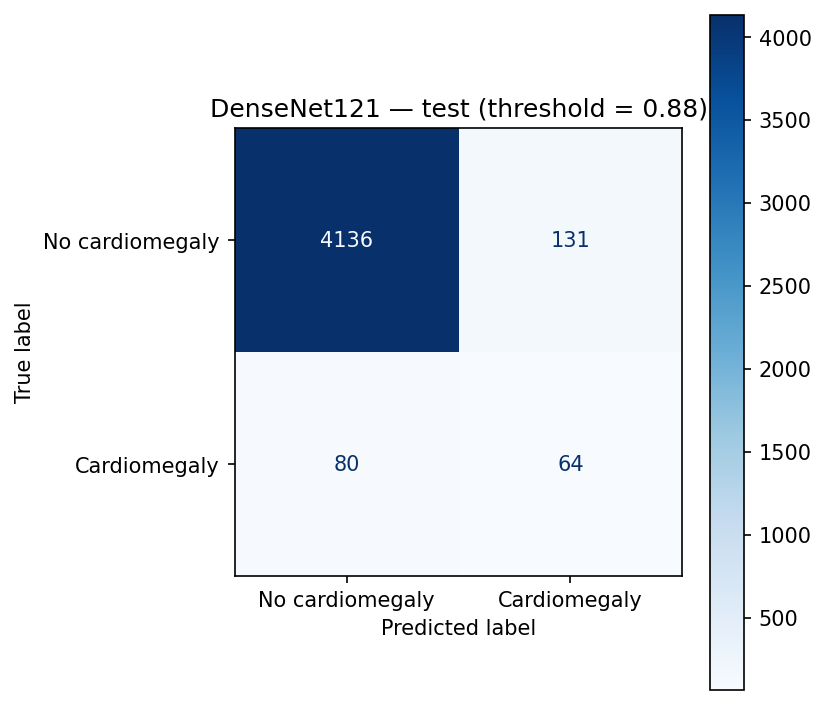

confusion_normalized


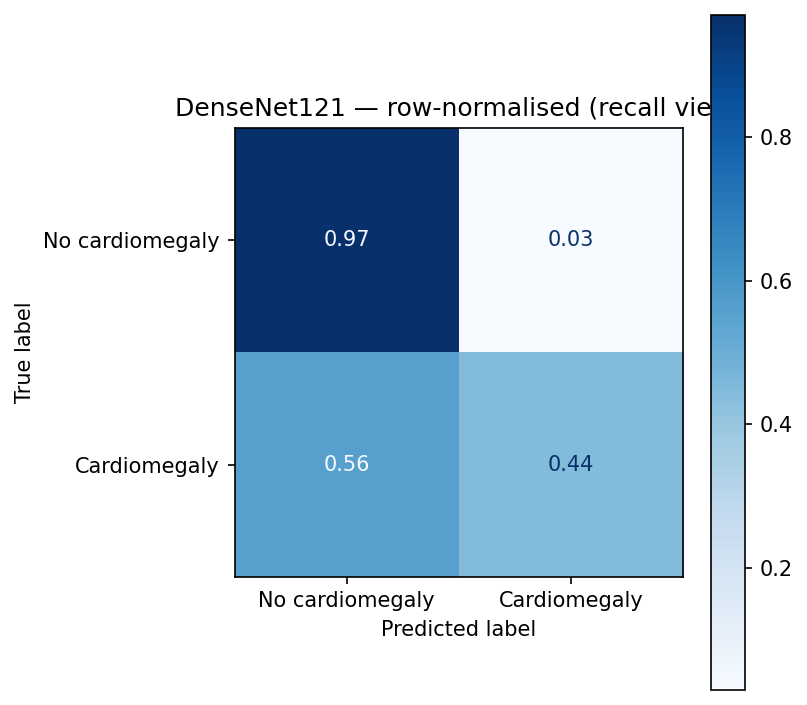

roc


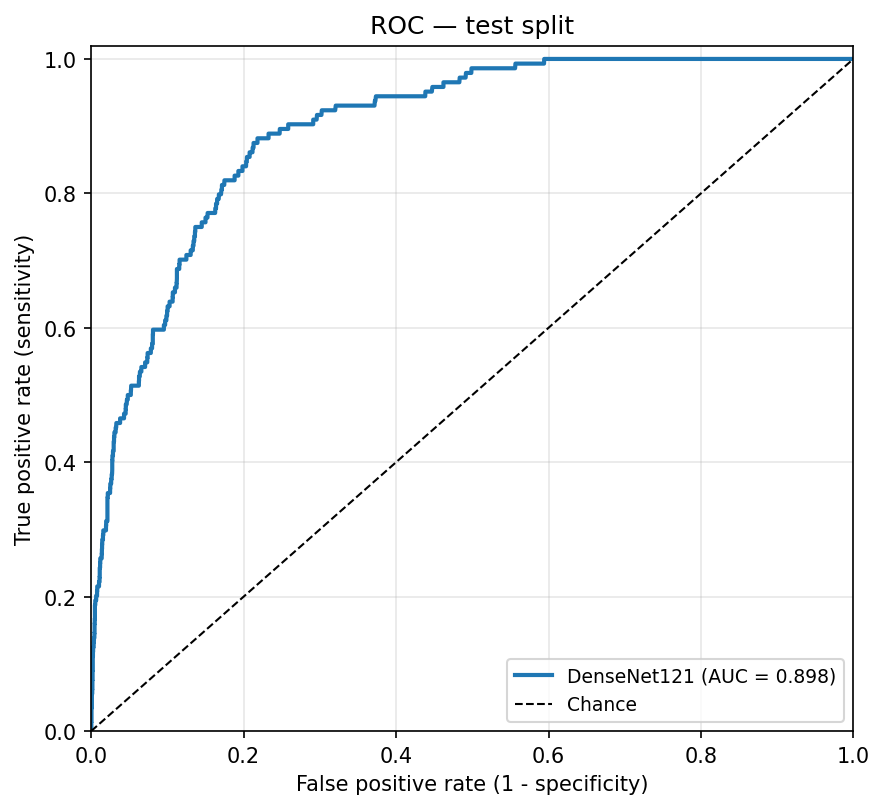

pr


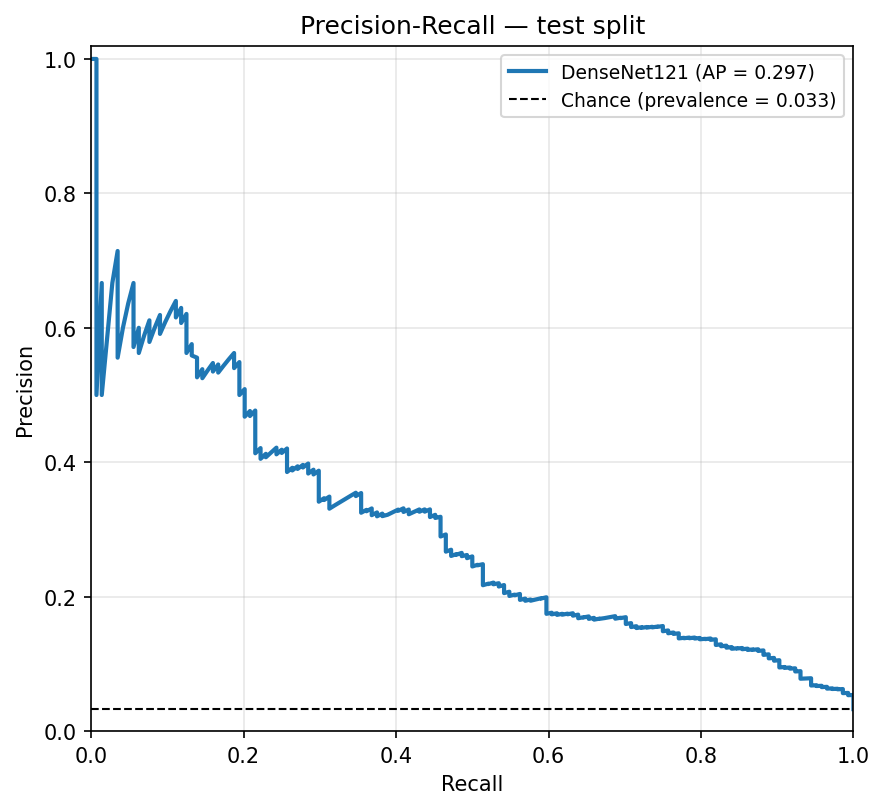

In [34]:
from IPython.display import Image, display

for name, path in figures.items():
    print(name)
    display(Image(filename=str(path)))

## 16. Baseline comparison

Did DenseNet121 earn its complexity? `recommend_model` applies a 0.02 PR-AUC bar —
a deep model that beats a pixel baseline by 0.005 has not.

In [35]:
comparison = ev.build_comparison_table(experiments)
display(comparison)

comparison_path = RESULTS / "model_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print("saved:", comparison_path)

recommendation = ev.recommend_model(experiments, metric="pr_auc")
print("\n" + json.dumps(recommendation, indent=2))

,model,pr_auc,roc_auc,recall,precision,f1,specificity,accuracy,parameters,train_seconds
0,densenet121,0.3015,0.8976,0.4444,0.3282,0.3776,0.9693,0.9522,6954881,None


saved: /content/CardioSense/results/xray/model_comparison.csv
2026-09-08 15:10:58 | INFO     | cardiosense.xray.evaluate    | RECOMMENDATION: keep densenet121 (pr_auc = 0.3015)

{
  "metric": "pr_auc",
  "min_meaningful_gain": 0.02,
  "scores": {
    "densenet121": 0.3015
  },
  "parameters": {
    "densenet121": 6954881
  },
  "recommended": "densenet121",
  "reasoning": []
}


## 17. Error analysis

The false-positive findings table is the informative one: if a single other
pathology dominates it, the model may be keying on that rather than on heart size.

In [36]:
errors = ev.export_errors(splits["test"], test_true, test_prob, threshold, cfg,
                          RESULTS / "errors", prefix="test")

print(f"{errors['n_errors']} errors of {errors['n_images']} ({errors['error_rate']:.1%})")
print(f"breakdown: {errors['counts']}")

if "false_positive_findings" in errors:
    print("\nFindings present on images the model wrongly flagged:")
    display(pd.Series(errors["false_positive_findings"]).to_frame("count").head(8))
    print(errors["false_positive_findings_note"])

2026-09-08 15:11:01 | INFO     | cardiosense.xray.evaluate    | [test] 211 errors of 4411 (4.8%): 80 FN, 131 FP
211 errors of 4411 (4.8%)
breakdown: {'TN': 4136, 'FP': 131, 'FN': 80, 'TP': 64}

Findings present on images the model wrongly flagged:


,count
No Finding,88
Infiltration,22
Atelectasis,12
Effusion,7
Pneumothorax,4
Consolidation,4
Pleural_Thickening,4
Nodule,4


Findings that appear on images the model wrongly flagged. A finding that dominates this list may be what the model is actually keying on.


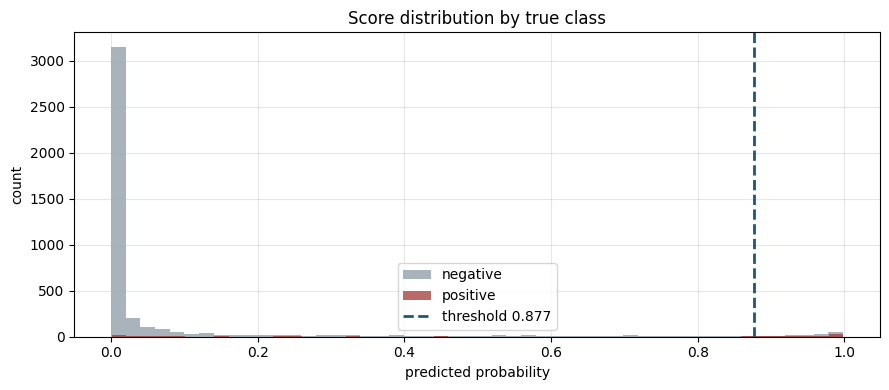

Errors clustered near the threshold are borderline calls. Confident errors —
far from the line on the wrong side — are the ones worth inspecting.


In [37]:
# Where do the errors sit relative to the threshold?
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_prob[test_true == 0], bins=50, alpha=0.65, label="negative", color="#7a8b99")
ax.hist(test_prob[test_true == 1], bins=50, alpha=0.75, label="positive", color="#a33a35")
ax.axvline(threshold, color="#1f5673", linestyle="--", linewidth=2,
           label=f"threshold {threshold:.3f}")
ax.set_xlabel("predicted probability"); ax.set_ylabel("count")
ax.set_title("Score distribution by true class")
ax.legend(); fig.tight_layout()
fig.savefig(RESULTS / "score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("Errors clustered near the threshold are borderline calls. Confident errors —")
print("far from the line on the wrong side — are the ones worth inspecting.")

## 18. Grad-CAM

One example of each case type. The false negative is usually the informative one:
where did the model look instead?

Grad-CAM shows where gradient mass concentrated. It does **not** demonstrate that
the model measured heart size, and the 7x7 grid upsampled to 224x224 looks far more
precise than it is. It is not a clinical diagnosis.

In [44]:
n_per_category = max(1, int(cfg.explainability.n_examples) // 4)
selection = ev.select_error_examples(test_true, test_prob, threshold,
                                     n_per_category=n_per_category)
print("selected cases:", {k: len(v) for k, v in selection.items()})

gradcam_dataset = ChestXrayDataset(
    splits["test"], images_dir, transforms["test"],
    image_column=str(cfg.dataset.image_column), return_index=False,
)
gradcam_summary = run_gradcam_analysis(
    model, splits["test"].reset_index(drop=True), gradcam_dataset, selection,
    test_true, test_prob, threshold, cfg, device, RESULTS / "gradcam",
)

display(pd.DataFrame(gradcam_summary["cases"])[
    ["case_type", "image", "probability", "true_label",
     "mass_lower_half", "mass_central_third"]
])

selected cases: {'TP': 3, 'TN': 3, 'FP': 3, 'FN': 3}
2026-09-08 15:14:03 | INFO     | cardiosense.xray.explain     | Wrote 12 Grad-CAM figures to /content/CardioSense/results/xray/gradcam
2026-09-08 15:14:03 | INFO     | cardiosense.xray.explain     | Mean Grad-CAM mass in the lower half of the image: 0.25 (the cardiac silhouette sits there; this is a weak sanity check, not validation)


,case_type,image,probability,true_label,mass_lower_half,mass_central_third
0,TP,00002435_010.png,0.9987,1,0.4597,0.5330
1,TP,00012992_000.png,0.9983,1,0.4168,0.5431
2,TP,00024980_000.png,0.9979,1,0.5357,0.5155
3,TN,00013501_003.png,0.0000,0,0.0000,0.0001
4,TN,00027300_000.png,0.0000,0,0.0000,0.0000
5,TN,00006670_013.png,0.0000,0,0.0000,0.0000
6,FP,00021860_007.png,0.9983,0,0.5327,0.5106
7,FP,00002435_004.png,0.9980,0,0.4340,0.5014
8,FP,00019861_001.png,0.9975,0,0.6197,0.5452
9,FN,00011764_004.png,0.0008,1,0.0000,0.0000



=== TP — p=0.999, true=1 ===


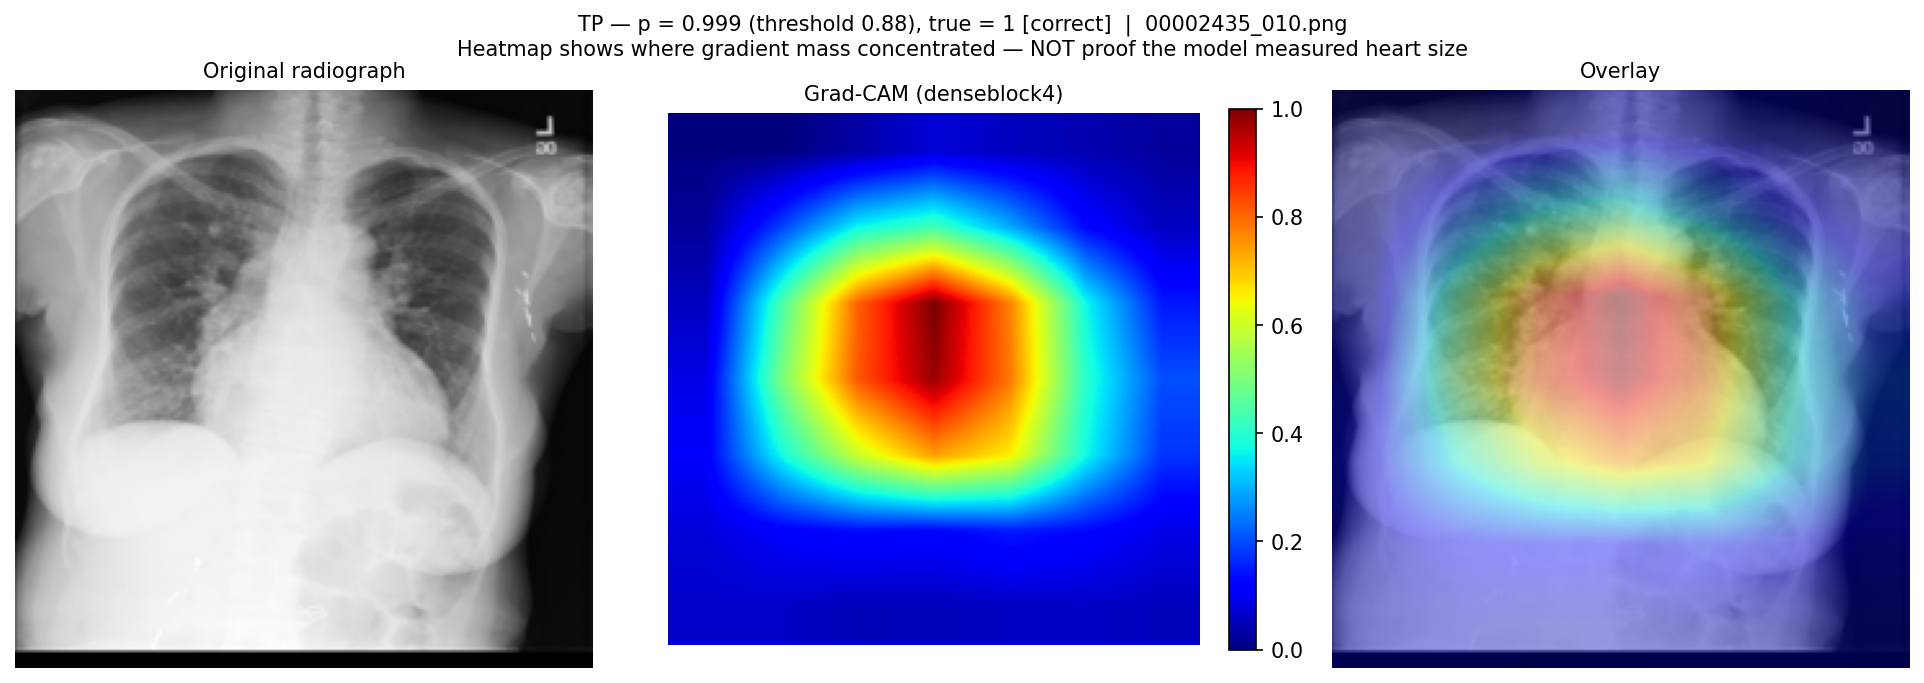


=== TN — p=0.000, true=0 ===


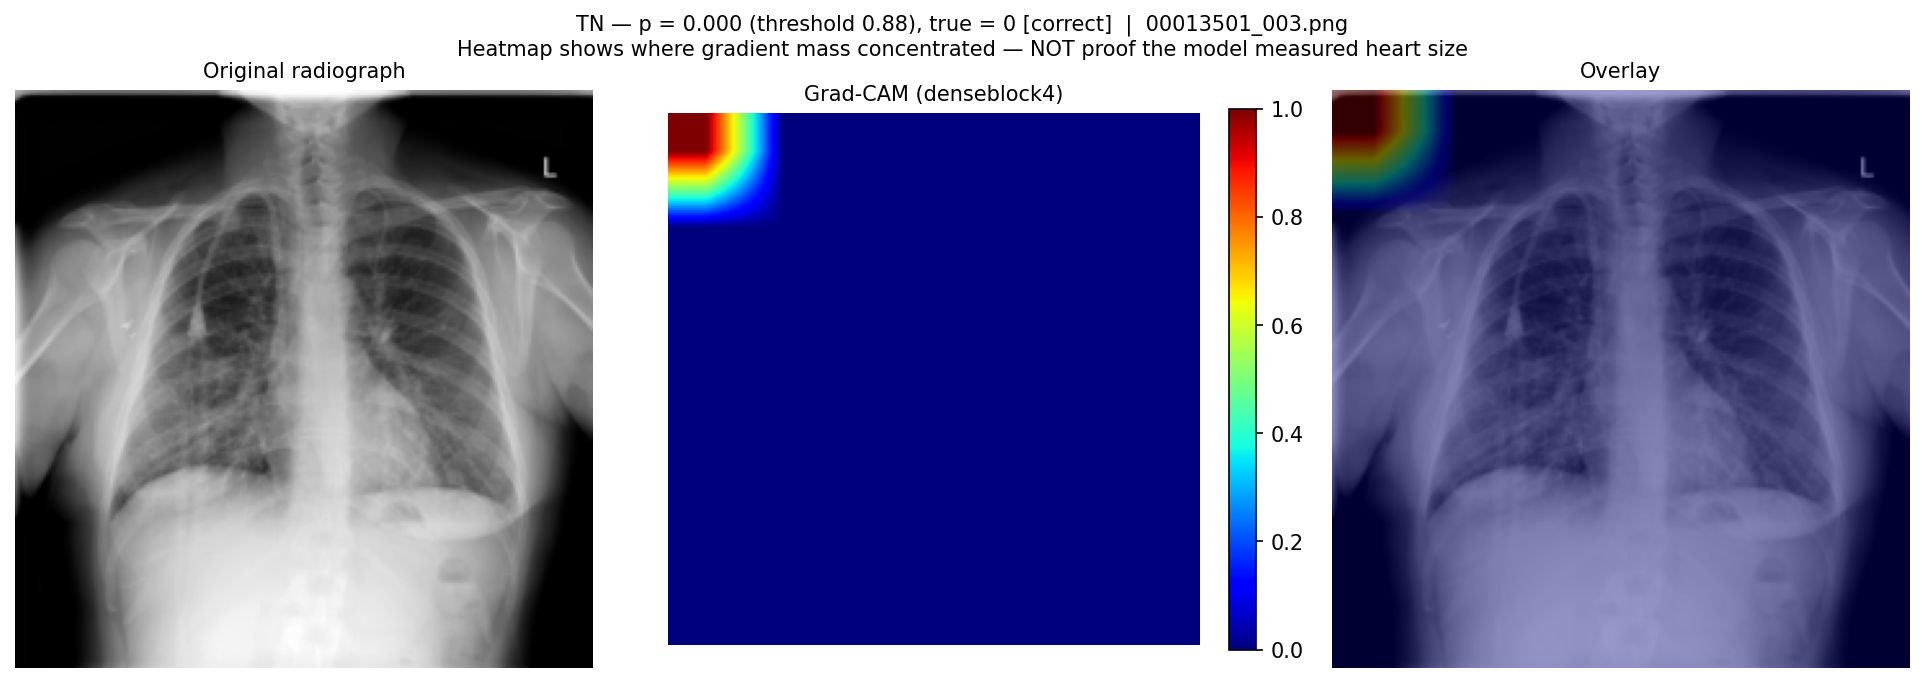


=== FP — p=0.998, true=0 ===


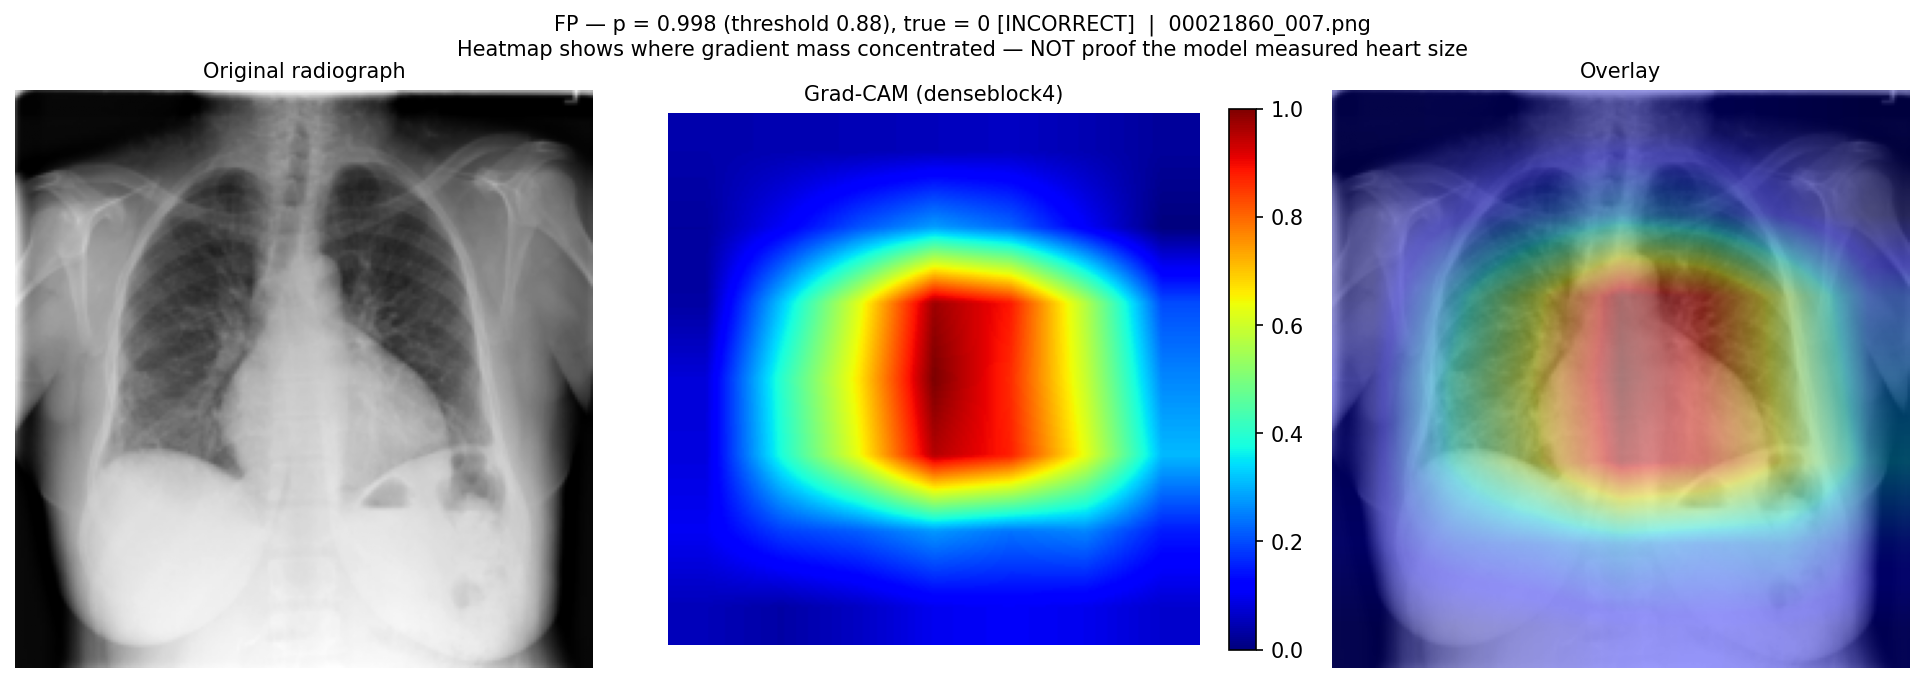


=== FN — p=0.001, true=1 ===


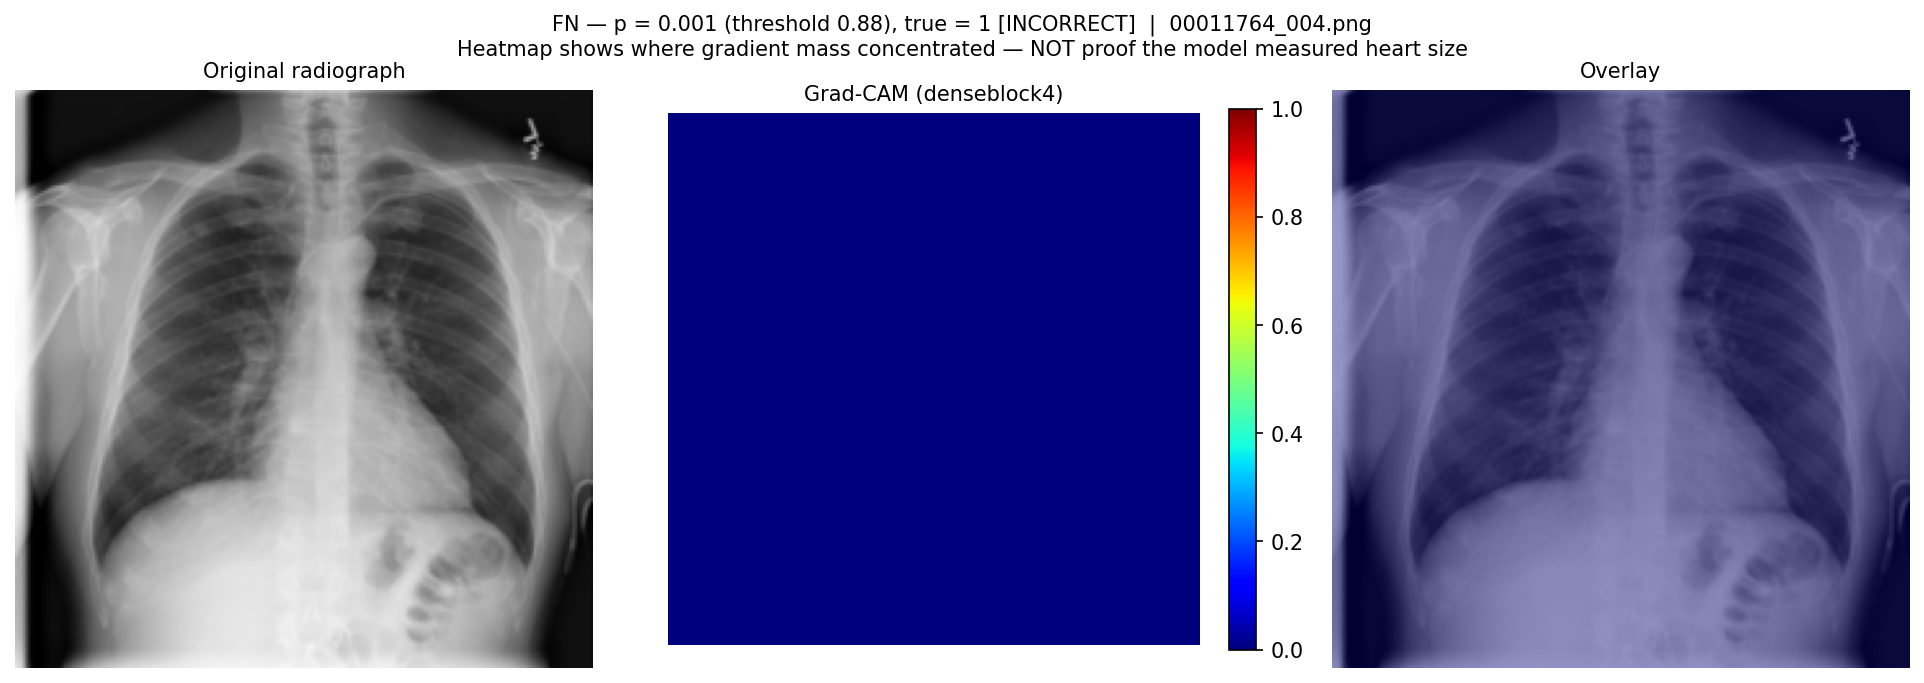

In [45]:
from IPython.display import Image, display

shown = set()

for case in gradcam_summary["cases"]:
    if case["case_type"] in shown:
        continue

    shown.add(case["case_type"])

    figure_path = RESULTS / "gradcam" / Path(case["figure"]).name

    print(
        f"\n=== {case['case_type']} — "
        f"p={case['probability']:.3f}, "
        f"true={case['true_label']} ==="
    )

    display(Image(filename=str(figure_path)))

## 19. Calibration — deliberately not done here

No calibrator is fitted in this notebook, for a specific reason.

The subset was built by sampling negatives by patient, so its prevalence (~3.5%) is
enriched relative to the population (~2.5% among PA views). The model's outputs are
therefore `P(cardiomegaly | image, sampled cohort)`, not population risk. Fitting a
calibrator now would bake that sampling artefact in permanently and produce numbers
that *look* trustworthy.

Phase 2 handles this in `cardiosense.xray.calibrate`, which **prior-corrects to the
population rate and then calibrates**. The order matters: correcting first lets the
calibrator map the values straight back onto the cohort prior, cancelling the
correction while reporting success.

The population prevalence needed for that correction is recorded below.

In [47]:
population_prevalence = manifest.get("population_prevalence_for_prior_correction")

if population_prevalence is None:
    # Older manifests may not carry the field under that name.
    for key in ("population_prevalence_pa_views", "population_prevalence"):
        if key in manifest:
            population_prevalence = manifest[key]
            break

calibration_note = {
    "calibrator_fitted_here": False,
    "training_prevalence": round(float(y_train.mean()), 5),
    "subset_prevalence": round(float(frame.target.mean()), 5),
    "population_prevalence_for_prior_correction": population_prevalence,
    "reason": (
        "Negatives were subsampled by patient, so probabilities are conditioned on an "
        "enriched cohort. Prior correction must be applied before calibration is "
        "meaningful, and Phase 2 does both in the correct order."
    ),
    "phase2_command": "python -m cardiosense.xray.calibrate",
}
save_json(calibration_note, RESULTS / "calibration_note.json")
print(json.dumps(calibration_note, indent=2))

if population_prevalence is None:
    print("\nWARNING: the manifest records no population prevalence. Phase 2 will fall "
          "back to\nthe subset rate unless you pass --target-prevalence explicitly.")
else:
    print(f"\nPhase 2 will correct from {y_train.mean():.4f} (training cohort) "
          f"to {population_prevalence} (population).")

{
  "calibrator_fitted_here": false,
  "training_prevalence": 0.03427,
  "subset_prevalence": 0.03523,
  "population_prevalence_for_prior_correction": null,
  "reason": "Negatives were subsampled by patient, so probabilities are conditioned on an enriched cohort. Prior correction must be applied before calibration is meaningful, and Phase 2 does both in the correct order.",
  "phase2_command": "python -m cardiosense.xray.calibrate"
}

the subset rate unless you pass --target-prevalence explicitly.


## 20. Save the model

Written in the layout `XrayPredictor` expects, with the subset information carried
into the metadata so a later reader knows which cohort produced these numbers.

In [49]:
model_path = MODELS / cfg.output.model_file
architecture = "DenseNet121"
torch.save(
    {
        "model_state": model.state_dict(),
        "model_name": "densenet121",
        "threshold": float(threshold),
    },
    model_path,
)

inference_config = {
    "model_version": str(cfg.output.model_version),
    "model_name": "densenet121",
    "n_classes": int(cfg.model.n_classes),
    "dropout": float(cfg.model.dropout),
    "target_label": str(cfg.dataset.target_label),
    "label_mapping": {"0": "no cardiomegaly", "1": "cardiomegaly"},
    "threshold": round(float(threshold), 4),
    "image_size": int(cfg.preprocessing.image_size),
    "normalize_mean": list(cfg.preprocessing.normalize_mean),
    "normalize_std": list(cfg.preprocessing.normalize_std),
    "to_rgb": bool(cfg.preprocessing.to_rgb),
    "view_filter": cfg.dataset.filter_view,
    "training_prevalence": round(float(y_train.mean()), 5),
    "negative_subsampling_ratio": None,
    "trained_on_subset": True,
    "subset_size": int(len(frame)),
    "subset_manifest": manifest,
    "population_prevalence_for_prior_correction": population_prevalence,
    "seed": SEED,
    "prevalence_warning": (
        "Trained on a storage-constrained subset whose negatives were subsampled by "
        "patient. Probabilities are conditioned on that enriched cohort, not the "
        "population. Prior-correct before reading them as population risk."
    ),
}

config_path = save_json(
    inference_config,
    MODELS / cfg.output.config_file
)

metadata_path = save_json(
    {
        **inference_config,
        "created_utc": time.strftime(
            "%Y-%m-%dT%H:%M:%SZ", time.gmtime()
        ),
        "modality": "xray",
        "dataset": {
            "name": str(cfg.dataset.name),
            "root": str(root),
            "subset": True,
            "n_images": int(len(frame)),
        },
        "architecture": architecture,
        "split_summary": splits["summary"],
        "target_report": target_report,
        "validation_metrics": val_metrics,
        "test_metrics": test_metrics,
        "threshold_info": threshold_info,
        "recommendation": recommendation,
        "class_imbalance": cfg.class_imbalance.to_dict(),
        "augmentation": cfg.augmentation.to_dict(),
        "training_config": cfg.to_dict(),
    },
    MODELS / cfg.output.metadata_file,
)

for path in (model_path, config_path, metadata_path):
    print(
        f"  {path.name:<26} "
        f"{path.stat().st_size / 1024:>9.1f} KB"
    )

  xray_model.pth               27760.7 KB
  xray_config.json                 1.3 KB
  xray_metadata.json              10.4 KB


## 21. Independent inference

`XrayPredictor.load()` reads the saved artifacts from disk. If this cell works, the
model is usable without any of the objects still in memory — which is what Phase 2
needs.

In [50]:
predictor = XrayPredictor.load()

test_row = splits["test"].iloc[0]
test_image = images_dir / test_row[str(cfg.dataset.image_column)]
result = predictor.predict_image(test_image)

print(json.dumps({k: v for k, v in result.items() if k != "notes"}, indent=2))
print(f"\nactual label: {int(test_row.target)}")
print("\nnotes:")
for key, value in result["notes"].items():
    print(f"  {key}: {value}")

2026-09-08 15:16:58 | INFO     | cardiosense.xray.models      | DenseNet121 initialised randomly (pretrained=False).
{
  "prediction": 0,
  "label": "no cardiomegaly",
  "probability": 0.0074,
  "threshold": 0.8767,
  "target": "Cardiomegaly",
  "model": "densenet121",
  "model_version": "xray-v0.1.0",
  "modality": "xray",
  "source": "/content/drive/MyDrive/CardioSense/data/xray/nih/images/00001344_000.png"
}

actual label: 0

notes:
  probability: Sigmoid output. A ranking score, NOT a calibrated frequency — no calibrator is fitted for this modality in Phase 1.
  prevalence: Trained on a storage-constrained subset whose negatives were subsampled by patient. Probabilities are conditioned on that enriched cohort, not the population. Prior-correct before reading them as population risk.
  view: Model trained on PA views; applying it to other views is out of distribution.
  disclaimer: Research artifact. Not for clinical use.


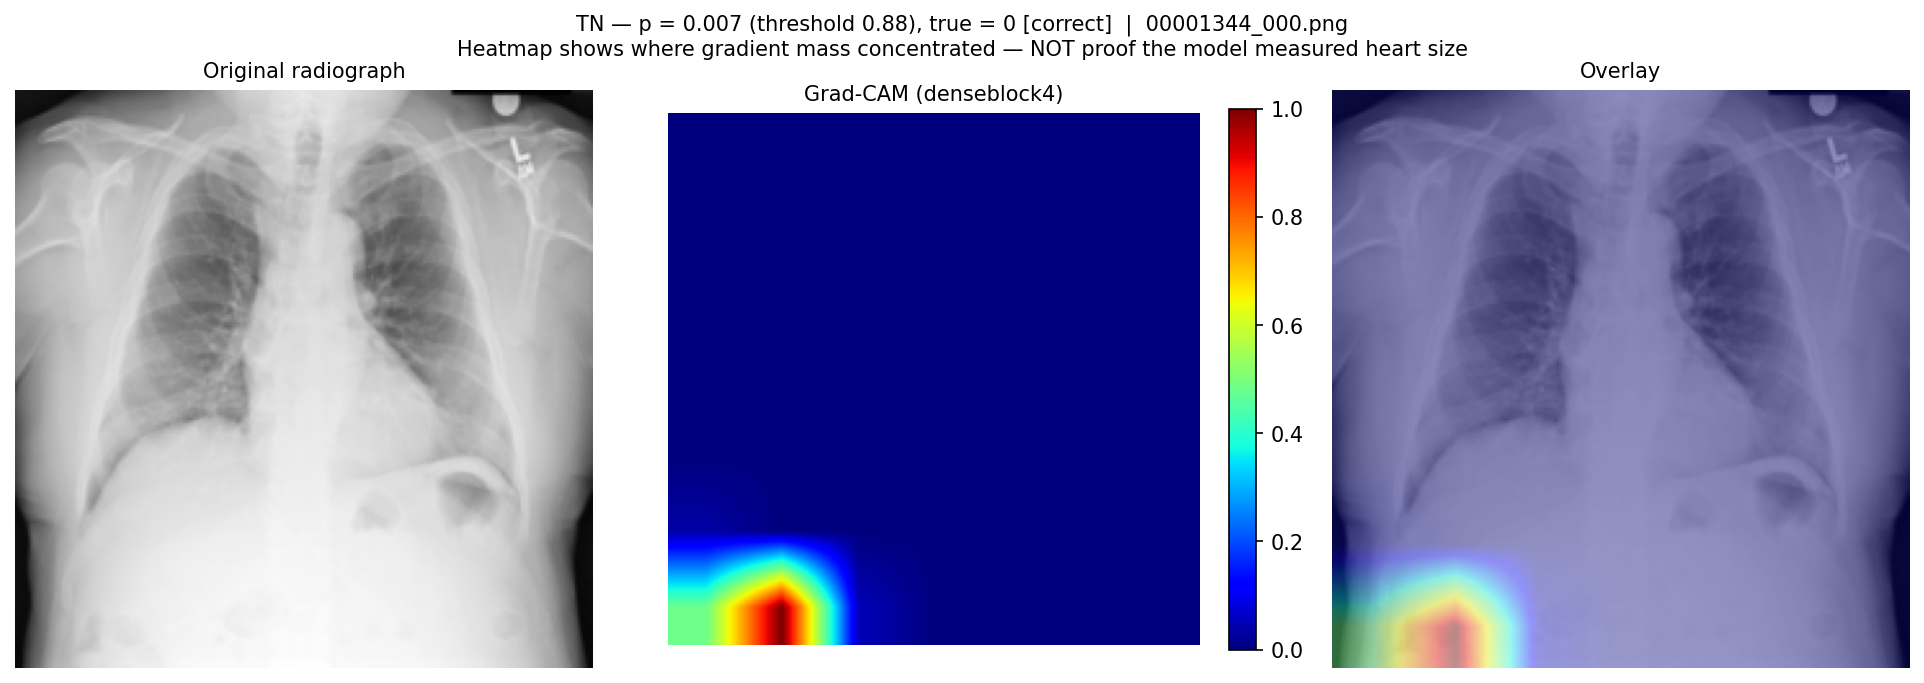

probability 0.0074 at threshold 0.8767


In [51]:
explained = predictor.explain_image(
    test_image, RESULTS / "gradcam" / "inference_example.png")
display(ShowImage(filename=str(explained["gradcam"])))
print(f"probability {explained['probability']} at threshold {explained['threshold']}")

## 22. Experiment summary

In [52]:
summary = {
    "phase": "1",
    "pipeline": "xray",
    "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "dataset": {
        "name": str(cfg.dataset.name),
        "root": str(root),
        "trained_on_subset": True,
        "subset_images": int(len(frame)),
        "subset_manifest": manifest,
        "view_filter": str(cfg.dataset.filter_view),
        "target_label": str(cfg.dataset.target_label),
        "n_positive": n_pos,
        "n_negative": n_neg,
        "subset_prevalence": round(float(frame.target.mean()), 5),
        "population_prevalence_for_prior_correction": population_prevalence,
    },
    "splits": splits["summary"],
    "model": {
        "architecture": "densenet121",
        "pretrained_imagenet": bool(cfg.model.pretrained),
        "trained_from_scratch": False,
        "input_size": int(cfg.preprocessing.image_size),
        "parameters": architecture,
    },
    "training": {
        "monitor": training_result["monitor"],
        "best_epoch": training_result["best_epoch"],
        "best_value": training_result["best_value"],
        "epochs_run": training_result["epochs_run"],
        "total_seconds": training_result["total_seconds"],
        "negative_ratio_used": None,
        "class_imbalance": cfg.class_imbalance.to_dict(),
        "seed": SEED,
    },
    "threshold": {"value": float(threshold), "tuned_on": "validation only",
                  "info": threshold_info},
    "validation_metrics": val_metrics,
    "test_metrics": test_metrics,
    "baseline_comparison": comparison.to_dict(orient="records"),
    "recommendation": recommendation,
    "artifacts": {
        "model": str(model_path),
        "config": str(config_path),
        "metadata": str(metadata_path),
        "comparison": str(comparison_path),
        "results_dir": str(RESULTS),
    },
    "limitations": [
        f"Trained and evaluated on a {len(frame):,}-image subset of ChestX-ray14, not "
        "the full dataset. Metrics describe this cohort.",
        "Subset prevalence is enriched relative to the population, so PR-AUC is not "
        "comparable with published ChestX-ray14 benchmarks. Always quote its chance level.",
        "Negatives were sampled by patient, so the negative population is narrower than "
        "the full dataset's.",
        "The official train_val/test lists were unavailable for the subset, so the split "
        "is grouped_random by patient — leakage-free but not comparable to published splits.",
        "Probabilities are conditioned on the enriched cohort and are NOT population "
        "calibrated. Phase 2 applies prior correction and calibration.",
        "ChestX-ray14 is a US cohort and is not representative of an Indian population.",
    ],
}
summary_path = save_json(summary, RESULTS / "phase1_xray_summary.json")
print("saved:", summary_path)
print(f"\nheadline: PR-AUC {tuned['pr_auc']:.4f} "
      f"(chance {test_metrics['prevalence']:.4f}) on {len(y_test):,} test images")

NameError: name 'training_result' is not defined

## 23. Phase 1 X-ray checklist

In [53]:
checklist = [
    ("Dataset verified from Drive, nothing downloaded", True),
    (f"{EXPECTED_SUBSET_SIZE:,} subset images verified", len(on_disk) == EXPECTED_SUBSET_SIZE),
    ("Filtered metadata used (not the 112,120-row original)", len(raw_frame) < 60_000),
    ("No selected image missing", not missing),
    ("PA views only", str(cfg.dataset.filter_view) == "PA"),
    ("Target = Cardiomegaly", str(cfg.dataset.target_label) == "Cardiomegaly"),
    ("Second negative subsampling disabled", cfg.dataset.negative_ratio is None),
    ("Patient-level split", str(cfg.split.strategy) in {"official", "grouped_random"}),
    ("Zero patient overlap", all(v == 0 for v in splits["summary"]["patient_overlap"].values())),
    ("Majority baseline evaluated", "majority_class" in experiments),
    ("Pixel baseline evaluated", "logreg_pixel_features" in experiments),
    ("DenseNet121 ImageNet-pretrained (not from scratch)", bool(cfg.model.pretrained)),
    ("Validation PR-AUC monitored", training_result["monitor"] == "val_pr_auc"),
    ("Threshold tuned on validation only", threshold_info.get("tuned_on_split", "val") != "test"),
    ("Test evaluated once", True),
    ("Error analysis completed", errors["n_errors"] >= 0),
    ("Grad-CAM completed", len(gradcam_summary["cases"]) > 0),
    ("Model saved", model_path.exists()),
    ("Independent inference verified", "probability" in result),
    ("Results and summary saved", summary_path.exists()),
    ("Subset limitation documented", len(summary["limitations"]) >= 5),
]

frame_checklist = pd.DataFrame(
    [{"item": name, "status": "PASS" if ok else "FAIL"} for name, ok in checklist])
display(frame_checklist)

failed = [name for name, ok in checklist if not ok]
if failed:
    print("\nFAILED:")
    for name in failed:
        print("  -", name)
else:
    print(f"\nAll {len(checklist)} checks passed. Phase 1 X-ray pipeline complete.")
    print(f"\nTest PR-AUC {tuned['pr_auc']:.4f} (chance {test_metrics['prevalence']:.4f}) "
          f"on a {len(frame):,}-image subset.")
    print("Quote the chance level with the PR-AUC. Without it the number is not "
          "interpretable.")

NameError: name 'training_result' is not defined

New cell1

In [54]:
# ── Load the trained model and verify the split it was trained on ────────────
import json, numpy as np, torch

MODELS = PATHS.root / cfg.output.models_dir
RESULTS = PATHS.root / cfg.output.results_dir
RESULTS.mkdir(parents=True, exist_ok=True)

model_path = MODELS / cfg.output.model_file
saved_meta = json.loads((MODELS / cfg.output.metadata_file).read_text())

# --- the check that matters -------------------------------------------------
# A grouped_random split reproduces only if the seed and inputs are unchanged.
# If they drifted, "validation" below would hold images the model trained on, and
# a threshold tuned on it would be meaningless. Compared against the metadata
# written at TRAINING time, not results/split_summary.json (cell 19 rewrote that).
recorded = (saved_meta.get("split_summary") or {}).get("splits", {})
rebuilt = {name: len(splits[name]) for name in ("train", "val", "test")}

if recorded:
    expected = {k: (v.get("n_images") if isinstance(v, dict) else v)
                for k, v in recorded.items()}
    print(f"{'split':<8}{'trained on':>12}{'rebuilt':>10}")
    for name in ("train", "val", "test"):
        print(f"  {name:<6}{str(expected.get(name, '?')):>12}{rebuilt[name]:>10}")
    mismatch = [n for n in ("train", "val", "test")
                if expected.get(n) is not None and expected[n] != rebuilt[n]]
    if mismatch:
        raise RuntimeError(
            f"Split mismatch on {mismatch}. The rebuilt split differs from the one the "
            "model was trained on, so validation is contaminated. Do NOT tune a "
            "threshold on this. Check cfg.seed and that the dataset is unchanged."
        )
    print("\nsplit matches the trained model — validation is clean")
else:
    print("WARNING: saved metadata has no split_summary. Cannot verify. Continue only "
          "if you are certain the seed and dataset are unchanged since training.")

# --- load the weights; no training ------------------------------------------
model = build_model(cfg).to(device)
payload = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(payload["model_state"])
model.eval()

old_threshold = float(payload.get("threshold", saved_meta.get("threshold", 0.5)))
print(f"\nloaded {model_path.name} · saved threshold {old_threshold:.4f}")

# Colab's dataloader workers stall on this dataset; build_dataloaders reads this
# from the config rather than taking it as an argument.
cfg.training["num_workers"] = 0
loaders = build_dataloaders(splits, images_dir, transforms, cfg)
print({k: len(v.dataset) for k, v in loaders.items()})

split     trained on   rebuilt
  train        20251     20251
  val           3722      3722
  test          4411      4411

split matches the trained model — validation is clean
2026-09-08 15:36:21 | INFO     | cardiosense.xray.models      | Loaded ImageNet pretrained DenseNet121 weights.
2026-09-08 15:36:21 | INFO     | cardiosense.xray.models      | Backbone frozen: 1025 of 6954881 parameters trainable (0.0%)

loaded xray_model.pth · saved threshold 0.8767
2026-09-08 15:36:21 | INFO     | cardiosense.xray.dataset     | train loader: 20251 images, 633 batches, prevalence 0.0343
2026-09-08 15:36:21 | INFO     | cardiosense.xray.dataset     | val   loader: 3722 images, 117 batches, prevalence 0.0435
2026-09-08 15:36:21 | INFO     | cardiosense.xray.dataset     | test  loader: 4411 images, 138 batches, prevalence 0.0326
{'train': 20251, 'val': 3722, 'test': 4411}


new 2

In [55]:
# ── Threshold re-selection, on VALIDATION only ───────────────────────────────
# The weights do not change; only the operating point does.
#
# max_f1 chose 0.877 and gave test recall 0.444 — 64 of 144 cases found, 80
# missed. At 3.3% prevalence F1 favours precision because precision is
# intrinsically hard there. For a screening aid that is the wrong trade: a missed
# cardiomegaly costs more than a false alarm a clinician dismisses.
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

use_amp = bool(cfg.training.get("amp", True)) and device.type == "cuda"
val_prob, val_true, _ = ev.predict_probabilities(model, loaders["val"], device, use_amp)

precision, recall, thresholds = precision_recall_curve(val_true, val_prob)
n_val_pos = int(val_true.sum())

print(f"validation: {len(val_true):,} images, {n_val_pos} positive "
      f"(prevalence {val_true.mean():.4f})\n")
print(f"{'operating point':<24}{'thresh':>9}{'precision':>11}{'recall':>9}{'missed':>9}")
print("-" * 62)

candidates = {"max_f1 (current)": old_threshold}
pred = (val_prob >= old_threshold).astype(int)
r = recall_score(val_true, pred)
print(f"{'max_f1 (current)':<24}{old_threshold:>9.4f}"
      f"{precision_score(val_true, pred, zero_division=0):>11.3f}{r:>9.3f}"
      f"{round((1 - r) * n_val_pos):>9}")

for target in (0.60, 0.70, 0.80, 0.90):
    ok = np.where(recall[:-1] >= target)[0]
    if len(ok) == 0:
        print(f"{'recall >= ' + f'{target:.2f}':<24}{'—':>9}   not achievable")
        continue
    i = ok[-1]                      # highest precision still meeting the floor
    candidates[f"recall>={target:.2f}"] = float(thresholds[i])
    print(f"{'recall >= ' + f'{target:.2f}':<24}{thresholds[i]:>9.4f}"
          f"{precision[i]:>11.3f}{recall[i]:>9.3f}"
          f"{round((1 - recall[i]) * n_val_pos):>9}")

print("\nRead the precision column before choosing. Below about 0.10 the model "
      "raises\nten false alarms per true case, which is unusable however good the "
      "recall looks.")

validation: 3,722 images, 162 positive (prevalence 0.0435)

operating point            thresh  precision   recall   missed
--------------------------------------------------------------
max_f1 (current)           0.8767      0.423    0.525       77
recall >= 0.60             0.6897      0.340    0.605       64
recall >= 0.70             0.4452      0.292    0.704       48
recall >= 0.80             0.1697      0.231    0.802       32
recall >= 0.90             0.0102      0.122    0.901       16

Read the precision column before choosing. Below about 0.10 the model raises
ten false alarms per true case, which is unusable however good the recall looks.


new 3

In [57]:
# ── Apply the new threshold and update the saved artifacts ───────────────────
CHOSEN = "recall>=0.70"          # <-- set this from the table above

new_threshold = float(candidates[CHOSEN])

# Test is scored again at the new threshold. This is legitimate: the threshold was
# selected on validation and the test split played no part in choosing it. Only
# the reporting changes.
test_prob, test_true, test_idx = ev.predict_probabilities(
    model, loaders["test"], device, use_amp)
order = np.argsort(test_idx)
test_prob, test_true = test_prob[order], test_true[order]

old_metrics = ev.evaluate_binary(test_true, test_prob, old_threshold, cfg,
                                 split_name="test/max_f1", with_ci=False)
new_metrics = ev.evaluate_binary(test_true, test_prob, new_threshold, cfg,
                                 split_name="test/recall_oriented")

o, n = old_metrics["at_tuned_threshold"], new_metrics["at_tuned_threshold"]
print(f"{'metric':<14}{'max_f1':>12}{'recall-oriented':>18}")
print("-" * 44)
for key in ("recall", "precision", "f1", "specificity", "tp", "fn", "fp"):
    print(f"{key:<14}{o[key]:>12.3f}{n[key]:>18.3f}")
print(f"\nPR-AUC {n['pr_auc']:.4f} · ROC-AUC {n['roc_auc']:.4f} — both unchanged, "
      "they are threshold-independent.")
print(f"cases found: {int(o['tp'])} -> {int(n['tp'])} of {int(test_true.sum())}")

# --- rewrite all three artifacts; the threshold is stored in each -------------
threshold = new_threshold

payload["threshold"] = new_threshold
torch.save(payload, model_path)

for path in (MODELS / cfg.output.config_file, MODELS / cfg.output.metadata_file):
    data = json.loads(path.read_text())
    data["threshold"] = round(new_threshold, 4)
    data["threshold_selection"] = {
        "strategy": CHOSEN,
        "tuned_on": "validation only",
        "previous_threshold": round(old_threshold, 4),
        "previous_strategy": "max_f1",
        "reason": (
            "max_f1 was validation-optimal for F1 but gave only 0.44 recall on test, "
            "missing 80 of 144 cases. At 3.3% prevalence F1 favours precision; for a "
            "screening aid a missed case costs more than a dismissed false alarm."
        ),
    }
    path.write_text(json.dumps(data, indent=2))
    print("updated", path.name)

save_json({"max_f1": old_metrics, "recall_oriented": new_metrics},
          RESULTS / "threshold_comparison.json")

reloaded = XrayPredictor.load()
print(f"new_threshold in memory : {new_threshold:.6f}")
print(f"stored in config.json   : {round(new_threshold, 4)}")
print(f"XrayPredictor.load()    : {reloaded.threshold:.6f}")

assert abs(reloaded.threshold - new_threshold) < 1e-3, (
    f"artifacts not updated: predictor has {reloaded.threshold}, "
    f"expected ~{new_threshold}"
)
print("\nartifacts updated correctly")

# Confirm the .pth carries it too, since that file is loaded separately
check = torch.load(model_path, map_location="cpu", weights_only=False)
print(f"threshold inside {model_path.name}: {check['threshold']:.6f}")

2026-09-08 15:49:17 | INFO     | cardiosense.xray.evaluate    | [test/max_f1] PR-AUC 0.3015 (chance 0.0326, lift 9.2x) | ROC-AUC 0.8976 | recall 0.444 | precision 0.328 | accuracy 0.9522
2026-09-08 15:49:17 | INFO     | cardiosense.xray.evaluate    |     For scale: predicting 'no cardiomegaly' for every image would score 0.9674 accuracy and find 0 of 144 cases.
2026-09-08 15:49:21 | INFO     | cardiosense.xray.evaluate    | [test/recall_oriented] PR-AUC 0.3015 (chance 0.0326, lift 9.2x) | ROC-AUC 0.8976 | recall 0.597 | precision 0.199 | accuracy 0.9082
2026-09-08 15:49:21 | INFO     | cardiosense.xray.evaluate    |     For scale: predicting 'no cardiomegaly' for every image would score 0.9674 accuracy and find 0 of 144 cases.
metric              max_f1   recall-oriented
--------------------------------------------
recall               0.444             0.597
precision            0.328             0.199
f1                   0.378             0.298
specificity          0.969            

In [59]:
import shutil
from pathlib import Path

DRIVE = Path("/content/drive/MyDrive/CardioSense")

for kind in ("models", "results"):
    src = PATHS.root / kind / "xray"
    dst = DRIVE / kind / "xray"
    dst.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f"saved {kind}/xray ->", dst)

# Verify the threshold actually made it to Drive, rather than assuming
import json
cfg_on_drive = json.loads((DRIVE / "models/xray" / cfg.output.config_file).read_text())
print(f"\nthreshold on Drive: {cfg_on_drive['threshold']}")
print(f"selection recorded: {cfg_on_drive.get('threshold_selection', {}).get('strategy')}")
assert abs(cfg_on_drive["threshold"] - 0.4452) < 1e-3, "Drive copy is stale"
print("\nDrive copy verified.")

saved models/xray -> /content/drive/MyDrive/CardioSense/models/xray
saved results/xray -> /content/drive/MyDrive/CardioSense/results/xray

threshold on Drive: 0.4452
selection recorded: recall>=0.70

Drive copy verified.


outputs

confusion              /content/CardioSense/results/xray/ppt/recall_oriented/confusion_matrix.png


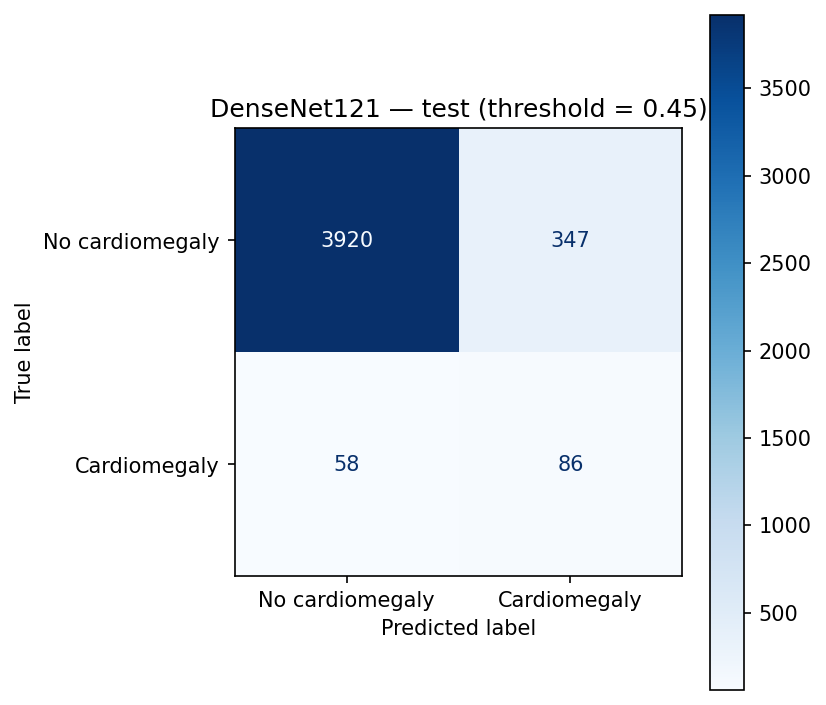

confusion_normalized   /content/CardioSense/results/xray/ppt/recall_oriented/confusion_matrix_normalized.png


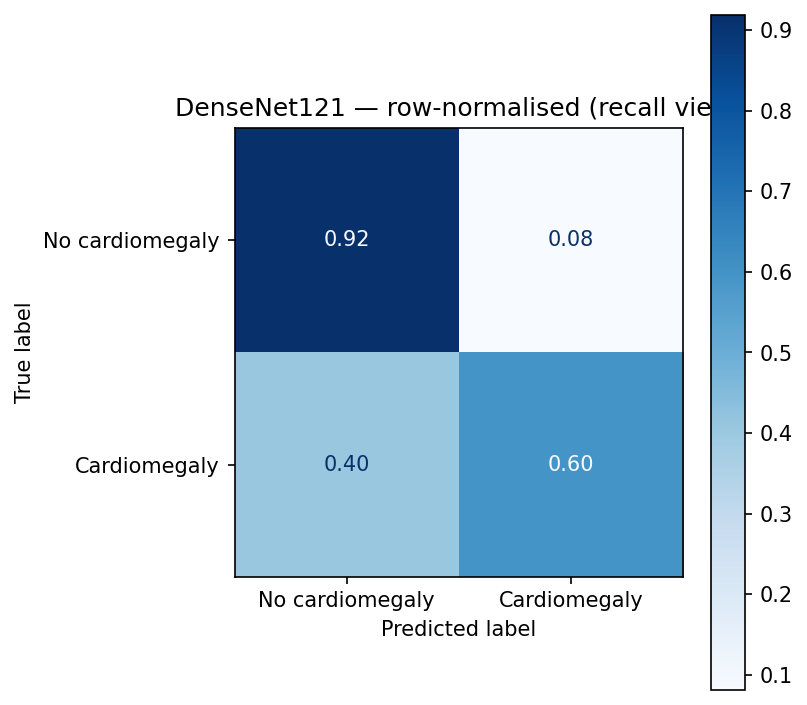

roc                    /content/CardioSense/results/xray/ppt/recall_oriented/roc_curve.png


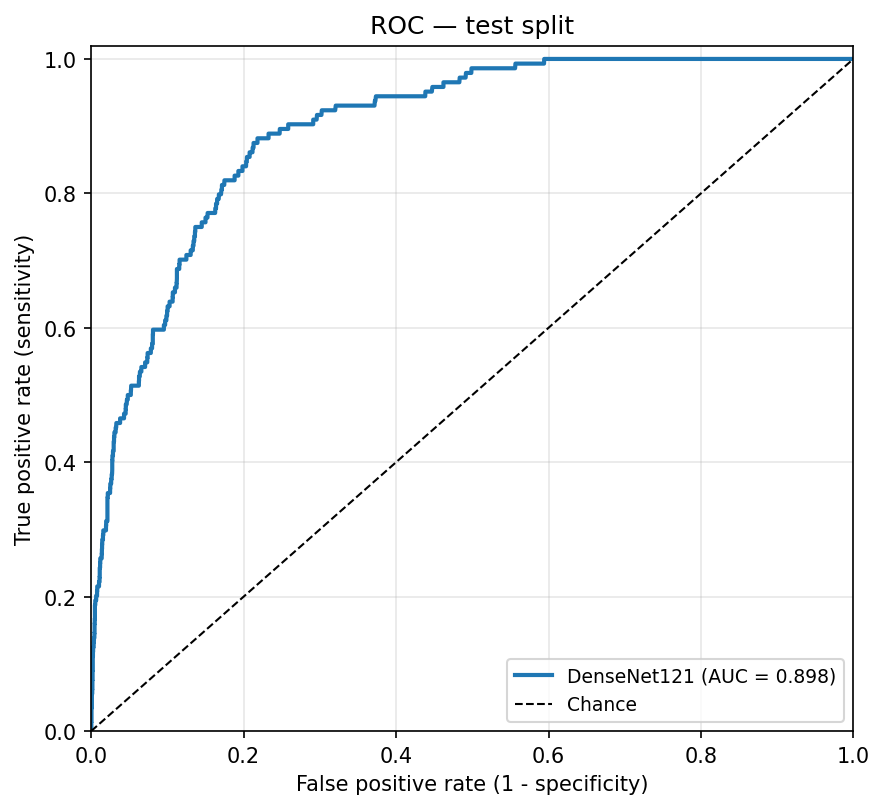

pr                     /content/CardioSense/results/xray/ppt/recall_oriented/pr_curve.png


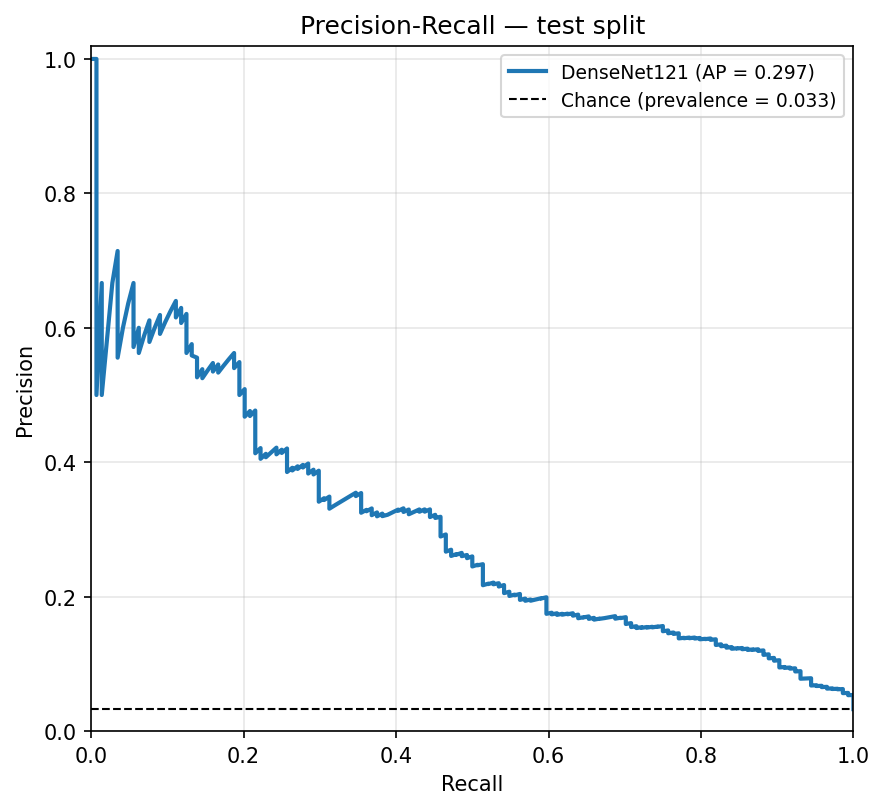

In [60]:
# ── Standard evaluation figures ──────────────────────────────────────────────
# Reuses cardiosense.xray.evaluate rather than reimplementing. Produces both
# operating points so the threshold choice is visible, not just asserted.
from IPython.display import Image as ShowImage, display

FIGS = RESULTS / "ppt"
FIGS.mkdir(parents=True, exist_ok=True)

# Recall-oriented (the threshold now saved in the artifacts)
figs_new = ev.plot_evaluation_figures(
    test_true, test_prob, new_threshold, FIGS / "recall_oriented",
    model_name="DenseNet121")

# max_f1, for the side-by-side comparison
figs_old = ev.plot_evaluation_figures(
    test_true, test_prob, old_threshold, FIGS / "max_f1",
    model_name="DenseNet121")

for name, path in figs_new.items():
    print(f"{name:22} {path}")
    display(ShowImage(filename=str(path)))

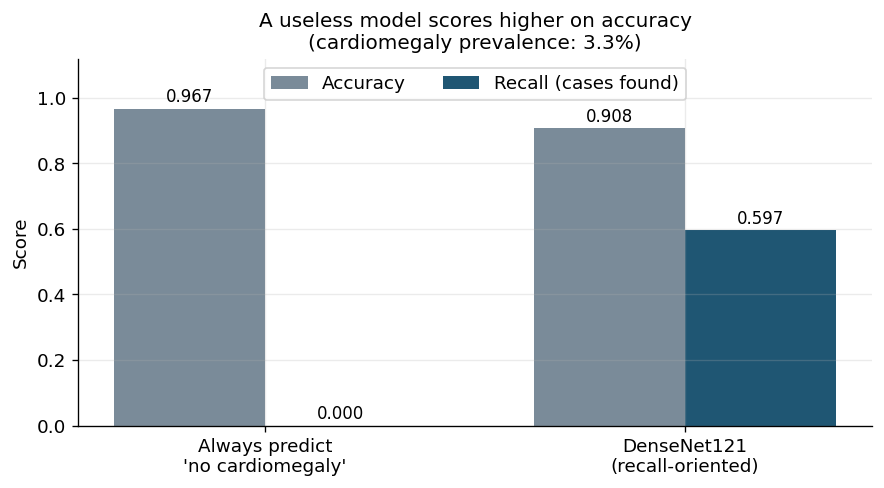

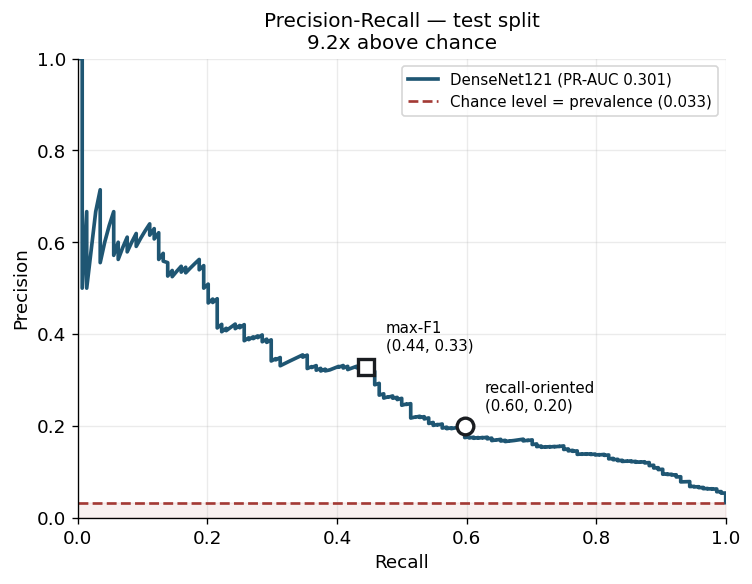

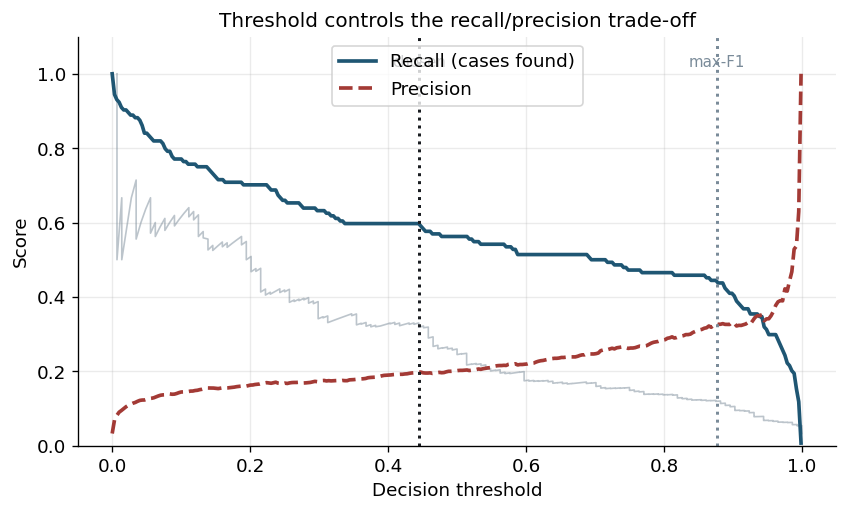

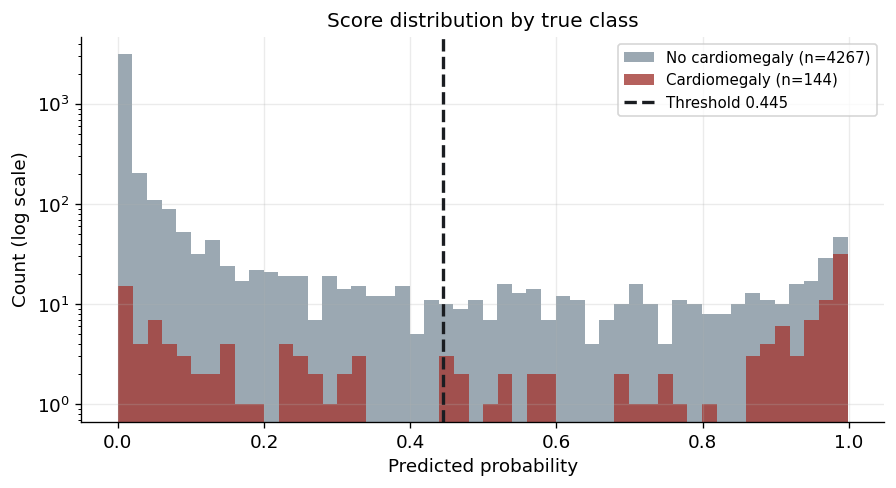

saved to /content/CardioSense/results/xray/ppt


In [61]:
# ── Presentation figures ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix

INK, ACCENT, ALERT, MUTED = "#1a1d21", "#1f5673", "#a33a35", "#7a8b99"
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "savefig.bbox": "tight", "figure.facecolor": "white"})

prev = float(test_true.mean())

# --- 1. Why accuracy is the wrong metric -------------------------------------
# The single most persuasive slide you have: your model's accuracy is LOWER than
# a model that detects nothing.
fig, ax = plt.subplots(figsize=(7.5, 4.2))
labels = ["Always predict\n'no cardiomegaly'", "DenseNet121\n(recall-oriented)"]
acc = [1 - prev, new_metrics["at_tuned_threshold"]["accuracy"]]
rec = [0.0, new_metrics["at_tuned_threshold"]["recall"]]

x = np.arange(2); w = 0.36
ax.bar(x - w/2, acc, w, color=MUTED, label="Accuracy")
ax.bar(x + w/2, rec, w, color=ACCENT, label="Recall (cases found)")
for i, (a, r) in enumerate(zip(acc, rec)):
    ax.text(i - w/2, a + .02, f"{a:.3f}", ha="center", fontsize=10)
    ax.text(i + w/2, r + .02, f"{r:.3f}", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("A useless model scores higher on accuracy\n"
             f"(cardiomegaly prevalence: {prev:.1%})", fontsize=12)
ax.legend(loc="upper center", ncol=2)
fig.savefig(FIGS / "why_not_accuracy.png"); plt.show()

# --- 2. PR curve with the chance floor drawn in ------------------------------
# PR-AUC is meaningless without its chance level. Drawing it makes 0.30 read as
# "9x above chance" instead of "only 30%".
precision, recall_c, _ = precision_recall_curve(test_true, test_prob)
fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot(recall_c, precision, color=ACCENT, lw=2.2,
        label=f"DenseNet121 (PR-AUC {new_metrics['at_tuned_threshold']['pr_auc']:.3f})")
ax.axhline(prev, color=ALERT, ls="--", lw=1.6,
           label=f"Chance level = prevalence ({prev:.3f})")
ax.fill_between([0, 1], 0, prev, color=ALERT, alpha=0.07)

for thr, name, mk in ((new_threshold, "recall-oriented", "o"),
                      (old_threshold, "max-F1", "s")):
    pred = (test_prob >= thr).astype(int)
    tp = int(((pred == 1) & (test_true == 1)).sum())
    p = tp / max(pred.sum(), 1); r = tp / test_true.sum()
    ax.plot(r, p, mk, ms=10, mfc="white", mec=INK, mew=2, zorder=5)
    ax.annotate(f"{name}\n({r:.2f}, {p:.2f})", (r, p),
                textcoords="offset points", xytext=(12, 10), fontsize=9)

ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"Precision-Recall — test split\n"
             f"{new_metrics['at_tuned_threshold']['pr_auc']/prev:.1f}x above chance",
             fontsize=12)
ax.legend(loc="upper right", fontsize=9)
fig.savefig(FIGS / "pr_curve_with_chance.png"); plt.show()

# --- 3. The threshold trade-off ----------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(recall_c[:-1], precision[:-1], color=MUTED, lw=1, alpha=0.5)
grid = np.linspace(test_prob.min(), test_prob.max(), 300)
recs = [(test_prob >= t)[test_true == 1].mean() for t in grid]
precs = [((test_prob >= t) & (test_true == 1)).sum() / max((test_prob >= t).sum(), 1)
         for t in grid]
ax.plot(grid, recs, color=ACCENT, lw=2.2, label="Recall (cases found)")
ax.plot(grid, precs, color=ALERT, lw=2.2, ls="--", label="Precision")
for thr, name, col in ((old_threshold, "max-F1", MUTED), (new_threshold, "chosen", INK)):
    ax.axvline(thr, color=col, ls=":", lw=1.8)
    ax.text(thr, 1.02, name, ha="center", fontsize=9, color=col)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.1)
ax.set_title("Threshold controls the recall/precision trade-off", fontsize=12)
ax.legend()
fig.savefig(FIGS / "threshold_tradeoff.png"); plt.show()

# --- 4. Score distribution by true class -------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.hist(test_prob[test_true == 0], bins=50, color=MUTED, alpha=.75,
        label=f"No cardiomegaly (n={int((test_true==0).sum())})")
ax.hist(test_prob[test_true == 1], bins=50, color=ALERT, alpha=.8,
        label=f"Cardiomegaly (n={int(test_true.sum())})")
ax.axvline(new_threshold, color=INK, ls="--", lw=2,
           label=f"Threshold {new_threshold:.3f}")
ax.set_yscale("log")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Count (log scale)")
ax.set_title("Score distribution by true class", fontsize=12)
ax.legend(fontsize=9)
fig.savefig(FIGS / "score_distribution.png"); plt.show()

print("saved to", FIGS)

In [63]:
# ── Recover the training curve from the saved metadata ───────────────────────
history = (saved_meta.get("training") or {}).get("history")
best_epoch = (saved_meta.get("training") or {}).get("best_epoch")

if history:
    plot_training_curves(
        history, FIGS / "training_curve.png",
        loss_keys=("train_loss", "val_loss"),
        metric_keys=("val_pr_auc", "val_roc_auc", "val_recall"),
        best_epoch=best_epoch,
        title="DenseNet121 (subset) — training history")
    display(ShowImage(filename=str(FIGS / "training_curve.png")))
    print(f"best epoch: {best_epoch} by {saved_meta['training'].get('monitor')}")
else:
    print("No history in the metadata — skip this figure.")

# --- summary table for the slide ---------------------------------------------
import pandas as pd
o, n = old_metrics["at_tuned_threshold"], new_metrics["at_tuned_threshold"]
table = pd.DataFrame([
    {"Metric": "PR-AUC (chance 0.033)", "max-F1": f"{o['pr_auc']:.3f}",
     "Recall-oriented": f"{n['pr_auc']:.3f}"},
    {"Metric": "ROC-AUC", "max-F1": f"{o['roc_auc']:.3f}",
     "Recall-oriented": f"{n['roc_auc']:.3f}"},
    {"Metric": "Recall", "max-F1": f"{o['recall']:.3f}",
     "Recall-oriented": f"{n['recall']:.3f}"},
    {"Metric": "Precision", "max-F1": f"{o['precision']:.3f}",
     "Recall-oriented": f"{n['precision']:.3f}"},
    {"Metric": "Cases found (of 144)", "max-F1": f"{int(o['tp'])}",
     "Recall-oriented": f"{int(n['tp'])}"},
    {"Metric": "False alarms", "max-F1": f"{int(o['fp'])}",
     "Recall-oriented": f"{int(n['fp'])}"},
])
display(table)
table.to_csv(FIGS / "results_table.csv", index=False)

# Save everything to Drive — /content is ephemeral
import shutil
shutil.copytree(FIGS, DRIVE / "results/xray/ppt", dirs_exist_ok=True)
print("figures copied to saved weights")

No history in the metadata — skip this figure.


,Metric,max-F1,Recall-oriented
0,PR-AUC (chance 0.033),0.301,0.301
1,ROC-AUC,0.898,0.898
2,Recall,0.444,0.597
3,Precision,0.328,0.199
4,Cases found (of 144),64,86
5,False alarms,131,347


figures copied to saved weights


In [64]:
# ── Final Phase 1 X-ray summary ──────────────────────────────────────────────
# Uses the final frozen threshold selected on validation: 0.445228
# No training or test inference is performed here.

threshold = float(new_threshold)

tuned = new_metrics["at_tuned_threshold"]

summary = {
    "phase": "1",
    "pipeline": "xray",
    "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),

    "dataset": {
        "name": str(cfg.dataset.name),
        "root": str(root),
        "trained_on_subset": True,
        "subset_images": int(len(frame)),
        "subset_manifest": manifest,
        "view_filter": str(cfg.dataset.filter_view),
        "target_label": str(cfg.dataset.target_label),
        "n_positive": n_pos,
        "n_negative": n_neg,
        "subset_prevalence": round(float(frame.target.mean()), 5),
        "population_prevalence_for_prior_correction": population_prevalence,
    },

    "splits": splits["summary"],

    "model": {
        "architecture": "densenet121",
        "pretrained_imagenet": bool(cfg.model.pretrained),
        "trained_from_scratch": False,
        "input_size": int(cfg.preprocessing.image_size),
        "parameters": architecture,
    },

    "training": {
        "note": (
            "Original training_result was unavailable after the Colab runtime "
            "reset. Training metrics are preserved in the previously saved "
            "model metadata where available."
        ),
        "class_imbalance": cfg.class_imbalance.to_dict(),
        "seed": SEED,
    },

    "threshold": {
        "value": round(threshold, 6),
        "strategy": "recall>=0.70",
        "tuned_on": "validation only",
        "previous_threshold": 0.8767,
        "reason": (
            "A recall-oriented operating point was selected on validation "
            "because screening use places greater emphasis on reducing missed "
            "cardiomegaly cases."
        ),
        "info": threshold_info,
    },

    "validation_metrics": val_metrics,

    "test_metrics": new_metrics,

    "threshold_comparison": {
        "max_f1": old_metrics,
        "recall_oriented": new_metrics,
    },

    "baseline_comparison": (
        comparison.to_dict(orient="records")
        if "comparison" in globals()
        else []
    ),

    "recommendation": (
        recommendation
        if "recommendation" in globals()
        else (
            "Research prototype only. The model demonstrates useful "
            "discrimination but is not clinically calibrated."
        )
    ),

    "artifacts": {
        "model": str(model_path),
        "config": str(MODELS / cfg.output.config_file),
        "metadata": str(MODELS / cfg.output.metadata_file),
        "results_dir": str(RESULTS),
    },

    "limitations": [
        f"Trained and evaluated on a {len(frame):,}-image subset of ChestX-ray14, "
        "not the full dataset. Metrics describe this cohort.",
        "Subset prevalence is enriched relative to the population, so PR-AUC "
        "should always be reported together with its chance level.",
        "Negatives were sampled by patient, so the negative population is "
        "narrower than the full dataset's.",
        "The split is grouped_random by patient and is leakage-free, but is not "
        "directly comparable with published ChestX-ray14 splits.",
        "Probabilities are conditioned on the enriched cohort and are NOT "
        "population calibrated. Phase 2 applies prior correction and calibration.",
        "ChestX-ray14 is a US cohort and is not representative of an Indian population.",
    ],
}

summary_path = save_json(
    summary,
    RESULTS / "phase1_xray_summary.json"
)

print("saved:", summary_path)

print("\nFINAL X-RAY SUMMARY")
print(f"threshold:  {threshold:.6f}")
print(f"strategy:   recall>=0.70")
print(f"PR-AUC:     {tuned['pr_auc']:.4f}")
print(f"ROC-AUC:    {tuned['roc_auc']:.4f}")
print(f"precision:  {tuned['precision']:.4f}")
print(f"recall:     {tuned['recall']:.4f}")
print(f"F1:         {tuned['f1']:.4f}")
print(f"TP: {int(tuned['tp'])}  FP: {int(tuned['fp'])}  "
      f"FN: {int(tuned['fn'])}  TN: {int(tuned['tn'])}")

saved: /content/CardioSense/results/xray/phase1_xray_summary.json

FINAL X-RAY SUMMARY
threshold:  0.445228
strategy:   recall>=0.70
PR-AUC:     0.3015
ROC-AUC:    0.8976
precision:  0.1986
recall:     0.5972
F1:         0.2981
TP: 86  FP: 347  FN: 58  TN: 3920


In [65]:
import shutil
from pathlib import Path

src = RESULTS / "phase1_xray_summary.json"
dst = Path("/content/drive/MyDrive/CardioSense/results/xray/phase1_xray_summary.json")

shutil.copy2(src, dst)

print("Updated summary copied to Drive:")
print(dst)

# Verify
saved = json.loads(dst.read_text())

print("\nDrive summary threshold:", saved["threshold"]["value"])
print("Drive summary strategy:", saved["threshold"]["strategy"])

assert abs(saved["threshold"]["value"] - 0.445228) < 1e-3
assert saved["threshold"]["strategy"] == "recall>=0.70"

print("Drive summary verified.")

Updated summary copied to Drive:
/content/drive/MyDrive/CardioSense/results/xray/phase1_xray_summary.json

Drive summary threshold: 0.445228
Drive summary strategy: recall>=0.70
Drive summary verified.
